In [1]:
library(tidyverse)
library(repr)
library(paletteer)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Data and Rates

In [2]:
tl_raw<- read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Tissue_Loss/T1-T4_Avg_Tissue_Loss.csv',show_col_types = FALSE)

In [3]:
tl_raw<-tl_raw %>%
    select(1:14) %>%
    select(-`immune_y/n`)
# create colony_id
tl_raw<-tl_raw %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [4]:
head(tl_raw)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,062019_TL,052022_TL,122022_TL,colony_id
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6/21/2019,CBC30N,1,1,SSID,5,45,24,5/21/2022,Diseased,82.5,37.5,25,T1_SSID_1
6/21/2019,CBC30N,1,2,PAST,4,33,8,Healthy,Healthy,97.5,95,97.5,T1_PAST_2
6/21/2019,CBC30N,1,3,SSID,5,53,30,5/21/2022,Diseased,95,95,92.5,T1_SSID_3
10/15/2019,CBC30N,1,4,PSTR,3,44,39,5/21/2022,12/2/2022,97.5,35,0,T1_PSTR_4
6/24/2019,CBC30N,1,5,SSID,5,65,27,5/21/2022,Diseased,97.5,35,27.5,T1_SSID_5
10/15/2019,CBC30N,1,6,PSTR,NA,35,38,12/2/2022,9/25/2023,100,100,62.5,T1_PSTR_6


In [5]:
# combine with colony data for health statuses
colony<-read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_ColonyData.csv',show_col_types = FALSE)

In [6]:
colony<-colony %>%
    select(TransectNum,NewTagNum,Species,`062019_Condition`,`102019_Condition`,`052022_Condition`,`122022_Condition`) %>%
    filter(!(TransectNum %in% c('5','6')))
# create colony_id
colony<-colony %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [7]:
head(colony,2)

TransectNum,NewTagNum,Species,062019_Condition,102019_Condition,052022_Condition,122022_Condition,colony_id
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,SSID,Healthy,NA,Diseased,Diseased,T1_SSID_1
1,2,PAST,Healthy,NA,Healthy,Healthy,T1_PAST_2


In [8]:
# merge by colony id 
tl<-tl_raw %>% 
    left_join(colony %>% select(-TransectNum,-NewTagNum,-Species), by = "colony_id")

In [9]:
# select diseased colonies only
conditions <- c('Diseased','Dead')
    # find diseased colonies
tl_dis_temp<-tl %>%
    filter(`052022_Condition` %in% conditions | `122022_Condition` %in% conditions)

diseased_colonies<-unique(tl_dis_temp$colony_id)
    # filter colonies
tl_dis<-tl %>%
    filter(colony_id %in% diseased_colonies)

In [10]:
# are there any colonies that were diseased in dec that were healthy in may?
nrow(tl %>%filter(`052022_Condition` == "Diseased"))
nrow(tl %>%filter(`122022_Condition` == "Diseased" & `052022_Condition` == "Healthy"))

[1] 33

[1] 6

In [11]:
length(unique(tl_dis_temp$colony_id))
length(unique(tl$colony_id))

[1] 81

[1] 152

In [12]:
nrow(tl)
nrow(tl_dis_temp)
nrow(tl_dis)

[1] 152

[1] 81

[1] 81

In [13]:
# pivot
tl_dis_long <- tl_dis %>% 
  pivot_longer(
    cols = matches("^\\d{6}_(Condition|TL)$"),
    names_to = c("Date", ".value"),
    names_pattern = "^(\\d{6})_(Condition|TL)$") %>%
  rename(tissue = TL)

In [14]:
head(tl_dis_long,6)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,colony_id,Date,tissue,Condition
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6/21/2019,CBC30N,1,1,SSID,5,45,24,5/21/2022,Diseased,T1_SSID_1,062019,82.5,Healthy
6/21/2019,CBC30N,1,1,SSID,5,45,24,5/21/2022,Diseased,T1_SSID_1,052022,37.5,Diseased
6/21/2019,CBC30N,1,1,SSID,5,45,24,5/21/2022,Diseased,T1_SSID_1,122022,25,Diseased
6/21/2019,CBC30N,1,1,SSID,5,45,24,5/21/2022,Diseased,T1_SSID_1,102019,NA,NA
6/21/2019,CBC30N,1,3,SSID,5,53,30,5/21/2022,Diseased,T1_SSID_3,062019,95,Healthy
6/21/2019,CBC30N,1,3,SSID,5,53,30,5/21/2022,Diseased,T1_SSID_3,052022,95,Diseased


In [15]:
# calculate rate of tl for diseased colonies
# change in TL over time
    # collect exact monitoring date
    # calculate number of weeks in between time points
    # calculate change in TL between time points
    # May and Dec: change in TL / number of weeks

In [16]:
# collect exact monitoring date

In [17]:
# add sampling date
samples<-read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_samples.csv',show_col_types = FALSE)

In [18]:
samples<-samples %>% 
    select(Month_year,CollectionDate,TransectNum,NewTagNum,Species) %>%
    distinct() %>%
    rename(Date = Month_year) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [19]:
# remove duplicate collectiondates
samples<-samples%>%distinct(colony_id,Date, .keep_all = TRUE)

In [20]:
tld<-tl_dis_long %>% 
    filter(!(is.na(Condition))) %>%
    left_join(samples %>% select(-TransectNum,-NewTagNum,-Species), by = c("colony_id","Date"))

In [21]:
# add in monitoring date
tld<-tld %>%
    mutate(fulldate = as.Date(CollectionDate,format = "%m/%d/%y"))
# if missing collectiondate,
# grab another fulldate from coral with same timepoint
tld <- tld %>%
  group_by(Date, Transect) %>%
  fill(fulldate, .direction = "downup") %>%
  ungroup()

In [22]:
unique(tld$tissue)

[1] "82.5"    "37.5"    "25"      "95"      "92.5"    "97.5"    "35"     
 [8] "0"       NA        "27.5"    "100"     "62.5"    "15"      "7.5"    
[15] "5"       "2.5"     "70"      "22.5"    "90"      "65"      "77.5"   
[22] "50"      "52.5"    "exclude" "60"      "55"      "32.5"    "67.5"   
[29] "n/a"     "45"      "20"      "10"      "85"      "40"      "57.5"   
[36] "87.5"

In [23]:
tld$tissue <- as.numeric(tld$tissue)
# remove NAs (entries were either NA or 'exclude' already)
tld <- tld %>% filter(!(is.na(tissue)))

Warning message:
“NAs introduced by coercion”


In [24]:
# drop colonies after they die
# id colonies with 0 tissue twice in a row and remove second time point
tld<- tld %>%
  group_by(colony_id) %>%
  arrange(fulldate, .by_group = TRUE) %>%
  mutate(dead_flag = cummax(as.numeric(tissue == 0 & lag(tissue, default = first(tissue)) == 0))) %>%
  filter(dead_flag == 0) %>%
  select(-dead_flag) %>%
  ungroup()

In [25]:
# calculate number of weeks in between time points
tld <- tld %>%
    group_by(colony_id) %>%
    arrange(fulldate, .by_group = TRUE) %>%
    mutate(diff_weeks = as.numeric(difftime(fulldate, lag(fulldate), units = "weeks"))) %>%
# calculate change in TL between time points
    mutate(diff_tl = tissue - lag(tissue)) %>%
    ungroup()

In [26]:
# calculate TL rates
tld<-tld %>%
    mutate(rate_abs = round(diff_tl / diff_weeks,2))

In [27]:
# avg TL rates per spp (2019 -> May, May -> Dec)
ratei<-tld %>%
    filter(Date == "052022") %>%
    group_by(Species) %>%
    summarise(mean_rate_abs1 = round(mean(rate_abs, na.rm = TRUE),2),
             sd_rate_abs1 = sd(rate_abs, na.rm = TRUE)) %>%
    arrange(mean_rate_abs1)

In [28]:
# avg TL rates per spp (May -> Dec)
ratef<-tld %>%
    filter(Date == "122022") %>%
    group_by(Species) %>%
    summarise(mean_rate_abs2 = round(mean(rate_abs, na.rm = TRUE),2),
              sd_rate_abs2 = sd(rate_abs, na.rm = TRUE))%>%
    arrange(mean_rate_abs2)

In [29]:
rates_abs<-left_join(ratei,ratef, by = "Species")

In [30]:
# or use percent change as numerator??
# tristin calculated percent change - got csv from his github: https://github.com/TristinH04/TissueLoss/blob/main/testgraphs/PercentAvg/T1-T4_Avg_Tissue_Loss_perchangeboth.csv
perchange<-read_csv("T1-T4_Avg_Tissue_Loss_perchangeboth.csv",show_col_types =  FALSE)

In [31]:
# keep sctld time points only 
pctd <- perchange %>%
    select(TransectNum,NewTagNum,Species,`062019_TL-052022_TL`,`052022_TL-122022_TL`) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum)) %>%
    rename("052022" = `062019_TL-052022_TL`,
          "122022" = `052022_TL-122022_TL`)

In [32]:
# filter colonies
pctd<-pctd %>%
    filter(colony_id %in% unique(tld$colony_id))

In [33]:
# pivot and merge 
pctd<-pctd %>%
    pivot_longer(cols = c('052022','122022'),
                names_to = "Date",
                values_to = "pctd_tl")
tld<-tld %>%
    left_join(pctd%>%select(-TransectNum,-NewTagNum,-Species), by = c('colony_id','Date'))

In [34]:
# calculate rates based on pct change
tld$pctd_tl <- as.numeric(tld$pctd_tl)
tld <- tld %>%   
    mutate(rate_pctd = round(pctd_tl / diff_weeks,2))

Warning message:
“NAs introduced by coercion”


In [35]:
tld %>%
    filter(Date == "122022" & Condition == "Dead")

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,14,MCAV,3,25,24,5/21/2022,12/2/2022,⋯,122022,0,Dead,NA,2022-12-02,27.85714,-70.0,-2.51,-100,-3.59
6/26/2019,CBC30N,1,15,MCAV,5,33,24,5/21/2022,12/2/2022,⋯,122022,0,Dead,NA,2022-12-02,27.85714,-22.5,-0.81,-100,-3.59
10/15/2019,CBC30N,1,4,PSTR,3,44,39,5/21/2022,12/2/2022,⋯,122022,0,Dead,NA,2022-12-02,27.85714,-35.0,-1.26,-100,-3.59
6/22/2019,SR30N,2,61,MCAV,4,27,20,NA,12/4/2022,⋯,122022,0,Dead,NA,2022-12-04,28.00000,-5.0,-0.18,-100,-3.57
10/13/2019,SR30N,2,58,PSTR,4,33,21,NA,12/2/2022,⋯,122022,0,Dead,NA,2022-12-04,28.00000,-100.0,-3.57,-100,-3.57
10/13/2019,SR30N,2,62,PSTR,5,65,70,NA,12/4/2022,⋯,122022,0,Dead,NA,2022-12-04,28.00000,-32.5,-1.16,-100,-3.57
10/13/2019,SR30N,2,70,PSTR,3,32,25,5/22/2022,12/4/2022,⋯,122022,0,Dead,NA,2022-12-04,28.00000,-27.5,-0.98,-100,-3.57
6/23/2019,LAGOON,3,17,MCAV,4,29,14,5/20/2022,12/3/2022,⋯,122022,0,Dead,NA,2022-12-03,28.14286,-37.5,-1.33,-100,-3.55
6/23/2019,LAGOON,3,22,MCAV,4,29,27,5/20/2022,12/3/2022,⋯,122022,0,Dead,NA,2022-12-03,28.14286,-57.5,-2.04,-100,-3.55


In [36]:
tl %>%
    filter(colony_id == "T2_PSTR_28")

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,062019_TL,052022_TL,122022_TL,colony_id,062019_Condition,102019_Condition,052022_Condition,122022_Condition
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
12/5/2022,SR30N,2,28,PSTR,NA,37,25,12/4/2022,9/26/2023,n/a,n/a,52.5,T2_PSTR_28,NA,NA,NA,Diseased


In [37]:
tld %>%
    filter(colony_id == "T1_SSID_10")

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,10,SSID,4,62,35,12/2/2022,9/25/2023,⋯,062019,97.5,Healthy,06/24/19,2019-06-24,NA,NA,NA,NA,NA
6/24/2019,CBC30N,1,10,SSID,4,62,35,12/2/2022,9/25/2023,⋯,052022,2.5,Diseased,05/21/22,2022-05-21,151.71429,-95,-0.63,-97.4359,-0.64
6/24/2019,CBC30N,1,10,SSID,4,62,35,12/2/2022,9/25/2023,⋯,122022,2.5,Diseased,12/02/22,2022-12-02,27.85714,0,0.00,0.0000,0.00


In [38]:
tld %>%
    filter(Date == '122022') %>%
    filter(is.na(diff_tl) | diff_tl == 0)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,10,SSID,4,62,35,12/2/2022,9/25/2023,⋯,122022,2.5,Diseased,12/02/22,2022-12-02,27.85714,0,0,0,0
6/24/2019,CBC30N,1,11,SSID,3,39,31,5/21/2022,Diseased,⋯,122022,7.5,Diseased,12/02/22,2022-12-02,27.85714,0,0,0,0
6/24/2019,CBC30N,1,16,SSID,5,115,55,5/21/2022,Diseased,⋯,122022,82.5,Diseased,12/04/22,2022-12-04,28.14286,0,0,0,0
12/5/2022,SR30N,2,30,OANN,NA,65,50,12/4/2022,Diseased,⋯,122022,95.0,Diseased,12/04/22,2022-12-04,NA,NA,NA,NA,NA
12/5/2022,SR30N,2,28,PSTR,NA,37,25,12/4/2022,9/26/2023,⋯,122022,52.5,Diseased,12/04/22,2022-12-04,NA,NA,NA,NA,NA
12/3/2022,LAGOON,3,67,MCAV,NA,19,37,12/3/2022,9/25/2023,⋯,122022,60.0,Diseased,12/03/22,2022-12-03,NA,NA,NA,NA,NA
6/23/2019,LAGOON,3,23,SSID,5,20,12,5/20/2022,Diseased,⋯,122022,5.0,Diseased,12/03/22,2022-12-03,28.14286,0,0,0,0
6/23/2019,LAGOON,3,36,SSID,3,35,24,5/20/2022,Diseased,⋯,122022,95.0,Healthy,12/03/22,2022-12-03,28.14286,0,0,0,0
12/5/2022,CURLEW,4,94,MCAV,NA,35,33,12/5/2022,9/26/2023,⋯,122022,32.5,Diseased,12/05/22,2022-12-05,NA,NA,NA,NA,NA


In [39]:
# avg TL rates per spp (2019 -> May, May -> Dec)
ratei<-tld %>%
    filter(Date == "052022") %>%
    group_by(Species) %>%
    summarise(mean_rate_pctd1 = round(mean(rate_pctd, na.rm = TRUE),2),
             sd_rate_pctd1 = sd(rate_pctd, na.rm = TRUE))

# avg TL rates per spp (May -> Dec)
ratef<-tld %>%
    filter(Date == "122022") %>%
    group_by(Species) %>%
    summarise(mean_rate_pctd2 = round(mean(rate_pctd, na.rm = TRUE),2),
             sd_rate_pctd2 = sd(rate_pctd, na.rm = TRUE))

rates_pctd<-left_join(ratei,ratef, by = "Species")

In [40]:
tld %>%
    filter(Date == "122022") %>%
    filter(diff_tl == -100)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10/13/2019,SR30N,2,58,PSTR,4,33,21,NA,12/2/2022,⋯,122022,0,Dead,NA,2022-12-04,28,-100,-3.57,-100,-3.57


In [41]:
rates<-left_join(rates_abs,rates_pctd,by = "Species")
rates
# 1 is 2019 - May 2022
# 2 is May 2022 -> Dec 2022

Species,mean_rate_abs1,sd_rate_abs1,mean_rate_abs2,sd_rate_abs2,mean_rate_pctd1,sd_rate_pctd1,mean_rate_pctd2,sd_rate_pctd2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMEA,-0.65,0.01943651,NA,NA,-0.66,0.003333333,NA,NA
MCAV,-0.49,0.18479590,-1.08,0.8355965,-0.50,0.181362568,-2.80,1.2020786
PSTR,-0.48,0.24051247,-1.90,1.1297330,-0.50,0.251899451,-3.20,0.9145636
SSID,-0.31,0.22916553,-0.33,0.4693363,-0.32,0.235824980,-0.74,0.8893243
PAST,-0.27,0.23259407,-0.40,0.9098351,-0.28,0.239937492,-0.41,0.9966736
DLAB,NaN,NA,-0.18,NA,NaN,NA,-0.19,NA
OANN,NaN,NA,-0.18,NA,NaN,NA,-0.18,NA
OFAV,NaN,NA,-0.36,NA,NaN,NA,-0.36,NA


In [42]:
# ok i think it makes more sense to compare rates from May -> Dec 2022 
    #since we don't know when outbreak occurred within the first time frame
# maybe can just compare avg tissue loss between species across initial time frame 
    # and then compare rates may -> dec?


In [43]:
# remove rates from initial timeframe and run ANOVA
    # idk if its better to use pct change or abs rates
    # i would think % change would standardize for initial differences in tissue loss but idk if this makes sense mathematically

### Assess Normality 

In [44]:
tld %>%
    group_by(Species) %>%
    summarise(n = length(unique(colony_id)))

Species,n
<chr>,<int>
DLAB,1
MCAV,18
MMEA,9
OANN,3
OFAV,1
PAST,5
PSTR,18
SSID,22


In [45]:
# remove 2019 from og df
tld2 <- tld %>% filter(!(Date %in% c('062019','102019')))
# remove any colonies with NA rates
tld2<-tld2 %>%
    filter(!(is.na(diff_tl)))

# remove low occurance spp 
tl_stats<-tld2 %>%
    group_by(Species) %>%
    # filter low occurance species
    filter(n() >= 3) %>%
    ungroup()

In [46]:
summary(tl_stats$rate_abs)
summary(tl_stats$rate_pctd)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.5700 -0.6550 -0.4600 -0.5495 -0.1800  0.4500 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.5900 -0.6600 -0.6400 -0.8475 -0.2400  0.6900 

In [47]:
# test for normality of response variable (rates)
shapiro.test(tl_stats$rate_abs)
# not normal


	Shapiro-Wilk normality test

data:  tl_stats$rate_abs
W = 0.74538, p-value = 4.486e-12


In [48]:
# install.packages("rstatix")
# install.packages("ggpubr")
library(rstatix)
# library(ggpubr)


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [49]:
# per group?
tl_stats %>%
    group_by(Species) %>%
    rstatix::shapiro_test(rate_abs) %>%
    filter(p < 0.05)
# non normal

Species,variable,statistic,p
<chr>,<chr>,<dbl>,<dbl>
MCAV,rate_abs,0.7478426,6.254932e-05
MMEA,rate_abs,0.7709570,9.474932e-03
PAST,rate_abs,0.8130611,2.875689e-02
PSTR,rate_abs,0.6969085,1.788055e-05
SSID,rate_abs,0.7651106,1.369733e-06


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


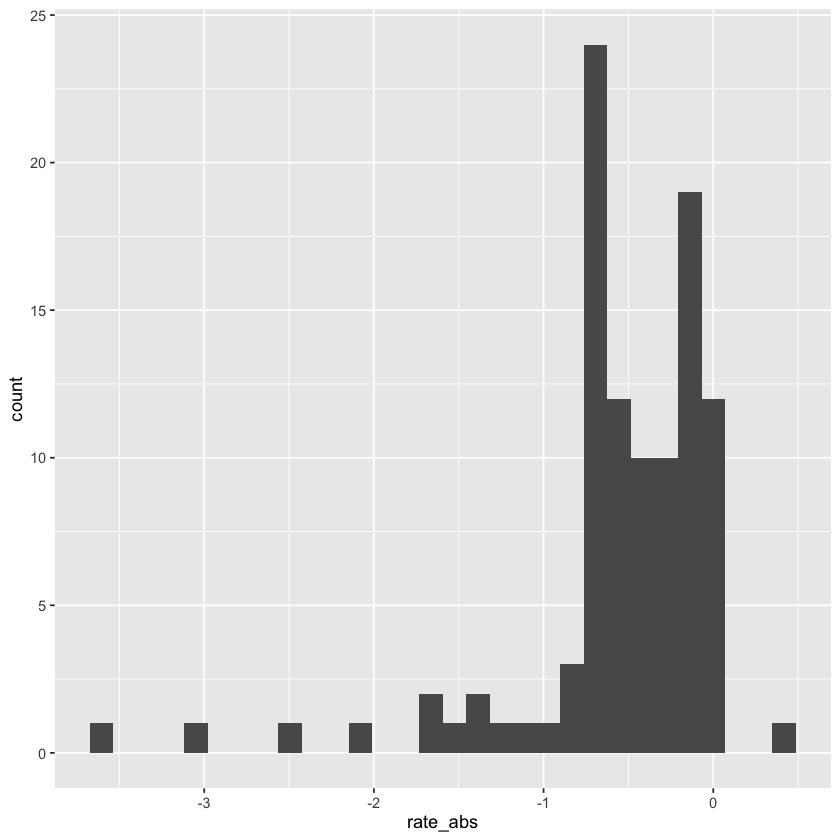

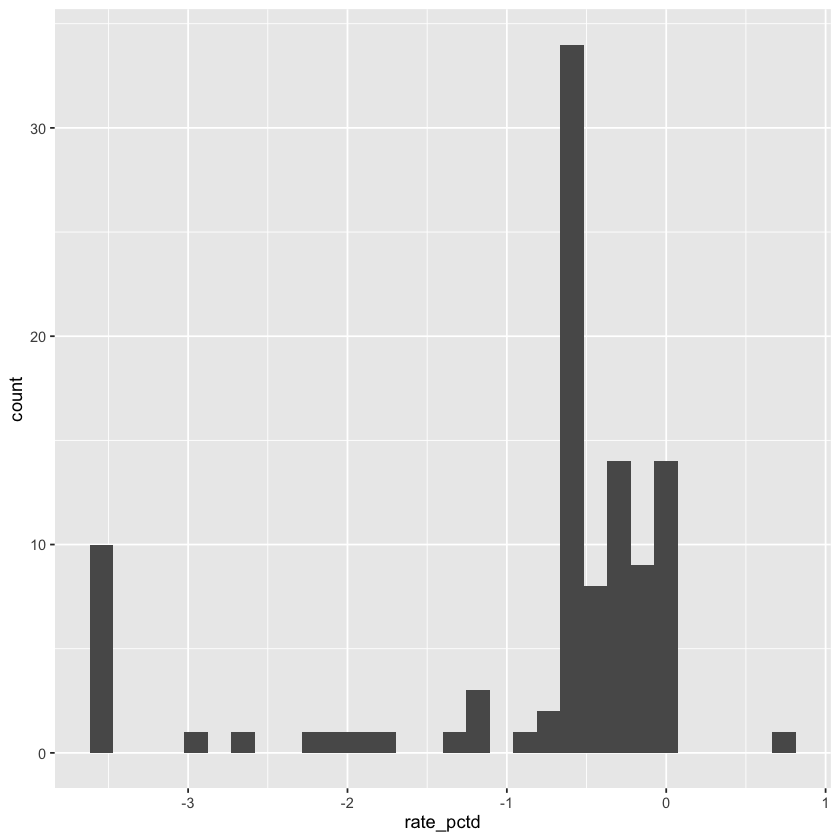

In [50]:
ggplot(tl_stats, aes(x = rate_abs))+
    geom_histogram()
ggplot(tl_stats, aes(x = rate_pctd))+
    geom_histogram()

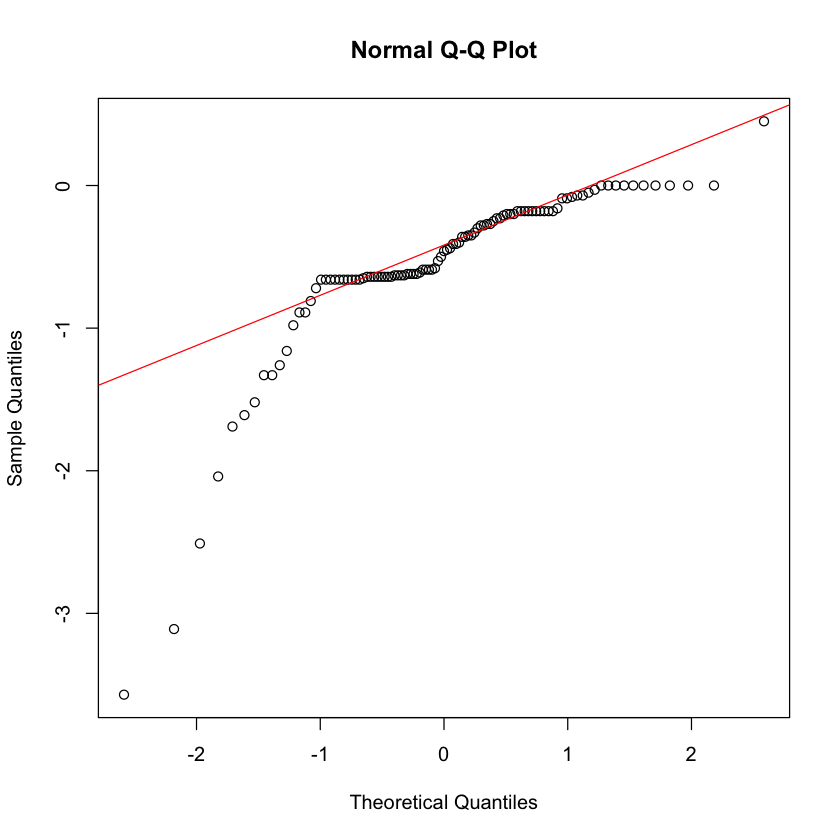

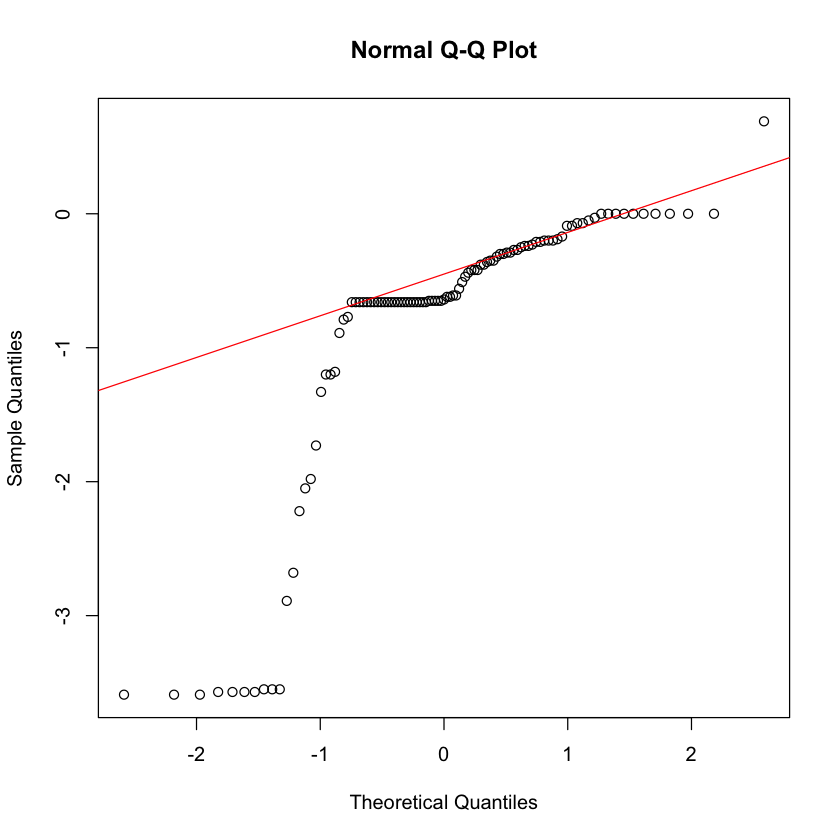

In [51]:
qqnorm(tl_stats$rate_abs)
qqline(tl_stats$rate_abs, col = "red")

qqnorm(tl_stats$rate_pctd)
qqline(tl_stats$rate_pctd, col = "red")

In [52]:
# non normal

In [53]:
summary(tl_stats$pctd_tl)
summary(tl_stats$diff_tl)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-100.00 -100.00  -63.16  -58.92  -21.83   19.23 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-100.00  -95.00  -42.50  -49.42   -7.50   12.50 

In [54]:
# percent change tissue loss (not rate)
tl_stats %>%
    group_by(Species) %>%
    # filter groups with 0 variance (MMEA)
    filter(n_distinct(pctd_tl) > 1) %>%
    rstatix::shapiro_test(pctd_tl) %>%
    filter(p < 0.05)
# not normal

Species,variable,statistic,p
<chr>,<chr>,<dbl>,<dbl>
MCAV,pctd_tl,0.7777189,0.0001721445
PSTR,pctd_tl,0.6327298,0.0000030523
SSID,pctd_tl,0.8671765,0.0002417639


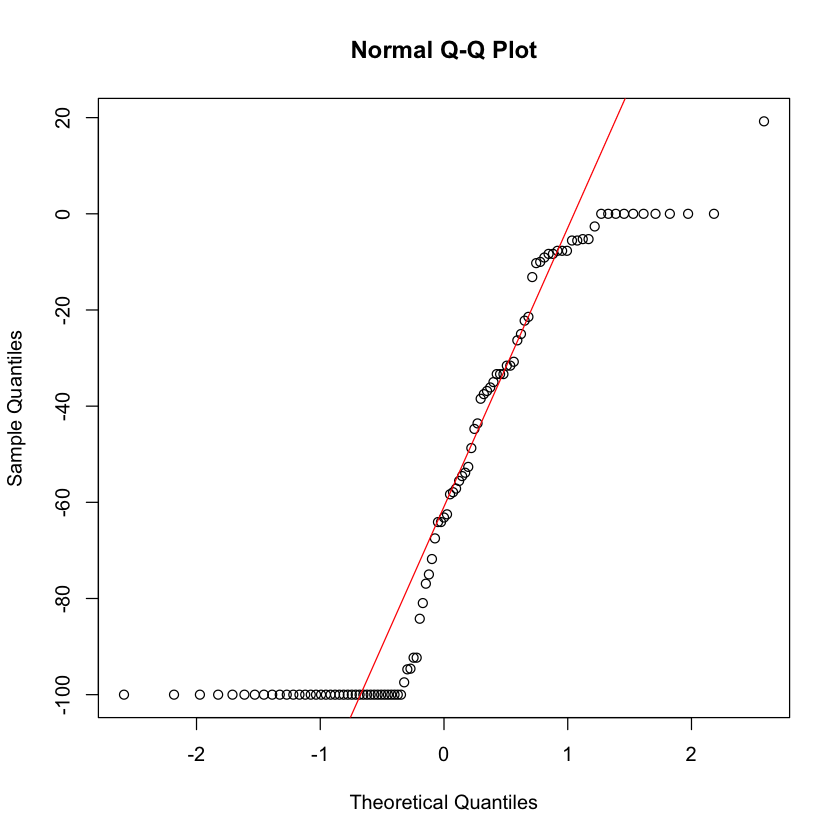

In [55]:
qqnorm(tl_stats$pctd_tl)
qqline(tl_stats$pctd_tl, col = "red")
# not normal but just has big tails

## Stats

In [56]:
# log transform? or use kruskall wallis or glmm instead of anova?? 

In [57]:
head(tl_stats,3)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,14,MCAV,3,25,24,5/21/2022,12/2/2022,⋯,052022,70.0,Diseased,05/21/22,2022-05-21,151.71429,-25,-0.16,-26.31579,-0.17
6/24/2019,CBC30N,1,14,MCAV,3,25,24,5/21/2022,12/2/2022,⋯,122022,0.0,Dead,NA,2022-12-02,27.85714,-70,-2.51,-100.00000,-3.59
6/26/2019,CBC30N,1,15,MCAV,5,33,24,5/21/2022,12/2/2022,⋯,052022,22.5,Diseased,05/21/22,2022-05-21,151.42857,-75,-0.50,-76.92308,-0.51


### Rates

In [58]:
# just use dec 2022 for rates
    # run on both absolute and relative rates

In [59]:
rates

Species,mean_rate_abs1,sd_rate_abs1,mean_rate_abs2,sd_rate_abs2,mean_rate_pctd1,sd_rate_pctd1,mean_rate_pctd2,sd_rate_pctd2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMEA,-0.65,0.01943651,NA,NA,-0.66,0.003333333,NA,NA
MCAV,-0.49,0.18479590,-1.08,0.8355965,-0.50,0.181362568,-2.80,1.2020786
PSTR,-0.48,0.24051247,-1.90,1.1297330,-0.50,0.251899451,-3.20,0.9145636
SSID,-0.31,0.22916553,-0.33,0.4693363,-0.32,0.235824980,-0.74,0.8893243
PAST,-0.27,0.23259407,-0.40,0.9098351,-0.28,0.239937492,-0.41,0.9966736
DLAB,NaN,NA,-0.18,NA,NaN,NA,-0.19,NA
OANN,NaN,NA,-0.18,NA,NaN,NA,-0.18,NA
OFAV,NaN,NA,-0.36,NA,NaN,NA,-0.36,NA


In [60]:
rates_plot<-rates %>%
    pivot_longer(cols = -Species,
             names_to = c("stat", "metric", "timepoint"),
             names_pattern = "(mean|sd)_rate_(abs|pctd)([12])") %>%
    pivot_wider(names_from = stat,
              values_from = value) %>%
    mutate(my = if_else(timepoint =="1","May 2022","Dec 2022"),
          my = factor(my,levels = c("May 2022","Dec 2022")))

rates_plot<-rates_plot %>% 
    filter(!(is.na(mean))) %>%
    # filter low occurance spp
    filter(!(Species %in% c('OFAV','OANN','DLAB')))


In [61]:
##### DEC ######

In [62]:
tl_dec<-tl_stats %>% filter(Date == "122022")

In [63]:
# absolute rates
# tl_dec %>%
#     kruskal_test(rate_abs ~ Species) %>%
#     mutate(sig = if_else(p<0.05,'YES','NO'))

# tl_dec %>%
#   dunn_test(rate_abs ~ Species, p.adjust.method = "bonferroni")

In [64]:
# ggplot(rates_plot%>%filter(metric=="abs"),aes(x = my, y = mean))+
#     geom_point()+
#     geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd),width = 0.2,color = "black",linewidth = 0.8)+
#     facet_wrap(~Species,scales = "free_y")

In [65]:
# relative rates
# excluded colonies that were dead in May
tl_dec %>%
    kruskal_test(rate_pctd ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_dec %>%
  dunn_test(rate_pctd ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_pctd,38,20.49219,3,0.0001341948,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_pctd,MCAV,PAST,8,4,2.4117508,0.0158761271,0.095256763,ns
2,rate_pctd,MCAV,PSTR,8,6,-0.4314235,0.6661604561,1.000000000,ns
3,rate_pctd,MCAV,SSID,8,20,3.3525721,0.0008006437,0.004803862,**
4,rate_pctd,PAST,PSTR,4,6,-2.6489425,0.0080744058,0.048446435,*
5,rate_pctd,PAST,SSID,4,20,-0.1358501,0.8919397541,1.000000000,ns
6,rate_pctd,PSTR,SSID,6,20,3.5135679,0.0004421313,0.002652788,**


In [66]:
# dec relative rates (pos statistic sp1 > sp2)
    # MCAV AND PSTR sig higher rates than SSID
    # PSTR sig higher rate than PAST

In [67]:
nrow(tl_dec)

[1] 38

In [69]:
rate_colonies <-unique(tl_dec$colony_id)

In [70]:
length(unique(tl_stats$colony_id))
length(rate_colonies)

[1] 67

[1] 38

In [71]:
tl_for_plot <- tl_stats %>%
    filter(colony_id %in% rate_colonies)

In [72]:
nrow(tl_stats)
nrow(tl_for_plot)

[1] 103

[1] 74

In [73]:
tl_for_plot %>%
    filter(Date == "052022" & tissue<10)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,10,SSID,4,62,35,12/2/2022,9/25/2023,⋯,052022,2.5,Diseased,05/21/22,2022-05-21,151.7143,-95.0,-0.63,-97.43590,-0.64
6/24/2019,CBC30N,1,11,SSID,3,39,31,5/21/2022,Diseased,⋯,052022,7.5,Diseased,05/21/22,2022-05-21,151.7143,-90.0,-0.59,-92.30769,-0.61
6/21/2019,CBC30N,1,9,SSID,5,38,18,5/21/2022,Diseased,⋯,052022,7.5,Diseased,05/21/22,2022-05-21,152.1429,-90.0,-0.59,-92.30769,-0.61
6/22/2019,SR30N,2,61,MCAV,4,27,20,NA,12/4/2022,⋯,052022,5.0,Healthy,05/22/22,2022-05-22,152.1429,-87.5,-0.58,-94.59459,-0.62
6/23/2019,LAGOON,3,23,SSID,5,20,12,5/20/2022,Diseased,⋯,052022,5.0,Diseased,05/20/22,2022-05-20,151.7143,-90.0,-0.59,-94.73684,-0.62


In [74]:
dec_relrates<-rates %>%
    select(Species,mean_rate_pctd2, sd_rate_pctd2) %>%
    filter(Species %in% c('PSTR','SSID','PAST','MCAV')) %>%
    arrange(mean_rate_pctd2)
dec_relrates

Species,mean_rate_pctd2,sd_rate_pctd2
<chr>,<dbl>,<dbl>
PSTR,-3.20,0.9145636
MCAV,-2.80,1.2020786
SSID,-0.74,0.8893243
PAST,-0.41,0.9966736


In [75]:
# look at avg and median tl per spp 
means<-tl_for_plot %>%
    group_by(Species,Date)%>%
    summarise(mean_tl = mean(pctd_tl),
             median_tl = median(pctd_tl),
             mean_tissue = mean(tissue)) %>%
    mutate(fulldate = case_when(
        Date == "052022" ~ min(tl_stats$fulldate),
        Date == "122022" ~ max(tl_stats$fulldate)))
means

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Species and Date.
ℹ Output is grouped by Species.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Species, Date))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


Species,Date,mean_tl,median_tl,mean_tissue,fulldate
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<date>
MCAV,052022,-56.27158,-58.114035,40.93750,2022-05-20
MCAV,122022,-78.49702,-100.000000,10.62500,2022-12-04
PAST,052022,-27.54217,-33.289474,70.62500,2022-05-20
PAST,122022,-11.56760,-8.391608,59.37500,2022-12-04
PSTR,052022,-35.60897,-37.179487,63.75000,2022-05-20
PSTR,122022,-89.58333,-100.000000,10.41667,2022-12-04
SSID,052022,-46.50084,-48.684211,51.11111,2022-05-20
SSID,122022,-20.75951,-8.012821,42.50000,2022-12-04


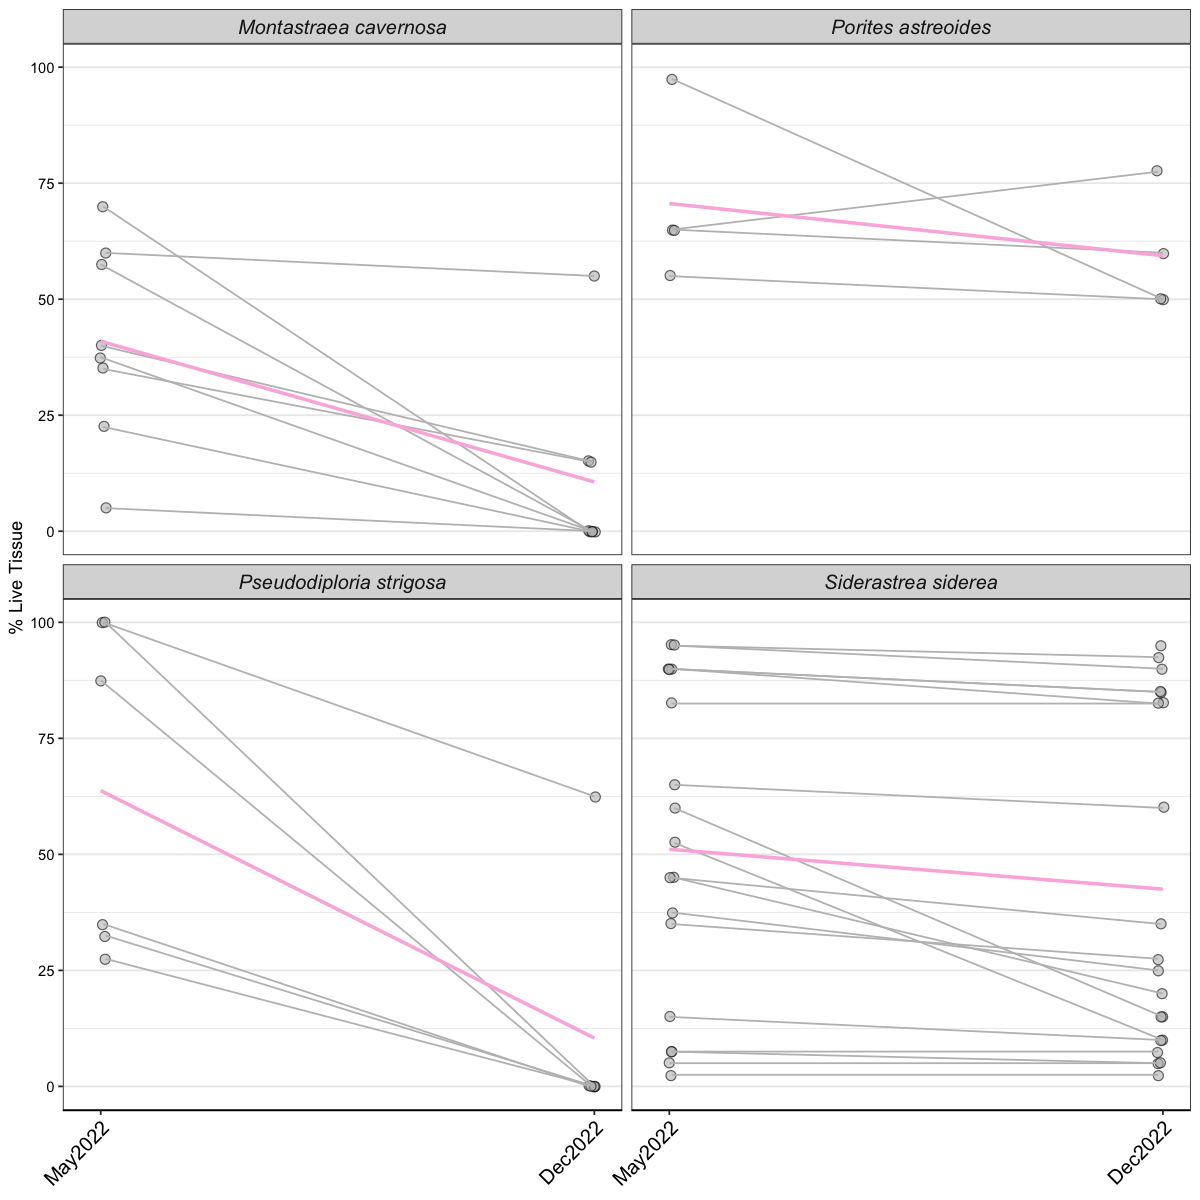

In [76]:
# copied Tristin's code
options(repr.plot.height = 10, repr.plot.width = 10)
custom_labels <- c(
  "MCAV" = "Montastraea cavernosa",
  "PAST" = "Porites astreoides",
  "PSTR" = "Pseudodiploria strigosa",
  "SSID" = "Siderastrea siderea")
tl_plot<-ggplot(tl_for_plot %>% filter(Species != "MMEA"), aes(x = fulldate, y = tissue, group = colony_id)) +
  geom_jitter(aes(fill=factor(colony_id)),shape=21, alpha = 0.6, size=2.5, fill = "grey", height = 0.2) +
  geom_path( color = "grey") +
  facet_wrap(~Species, labeller = labeller(Species = custom_labels))+
  geom_line(data = means%>%filter(Species != "MMEA"), aes(x = fulldate, y = mean_tissue, group = 1), color = "#fab6df", linewidth = 1)+
  labs(x = "Date",
       y = "% Live Tissue") +
  theme_bw() + 
  scale_x_date(limits = c(as.Date('2022-05-15'), as.Date('2022-12-05')),breaks = unique(means$fulldate), date_labels = '%b%Y') +
  theme(panel.background = element_blank(), axis.line.x = element_line(colour = "black"),
        panel.grid.major.x = element_blank(), panel.grid.minor.x = element_blank(),
        # panel.grid = element_blank(),
        strip.text = element_text(size = 12, face = "italic"),
        axis.text.x = element_text(colour = "black", angle = 45, hjust = 1, size = 12),
        axis.text = element_text(colour = "black"),
        axis.title.x = element_blank())
tl_plot
# excluding colonies that were dead in May
# pink is the mean % tissue at each time point per species

In [77]:
ggsave("tl_plot.png",tl_plot, width = 9, height = 8, units = "in", dpi = 400)

In [78]:
# convert live tissue to proportion and use ordbeta as in bleaching analysis
tl_stats<-tl_stats %>%
    mutate(prop_tissue = tissue/100)

In [79]:
# install.packages('ggpubr')
library(ggpubr)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] "Peason corr: 0.260198806742033"


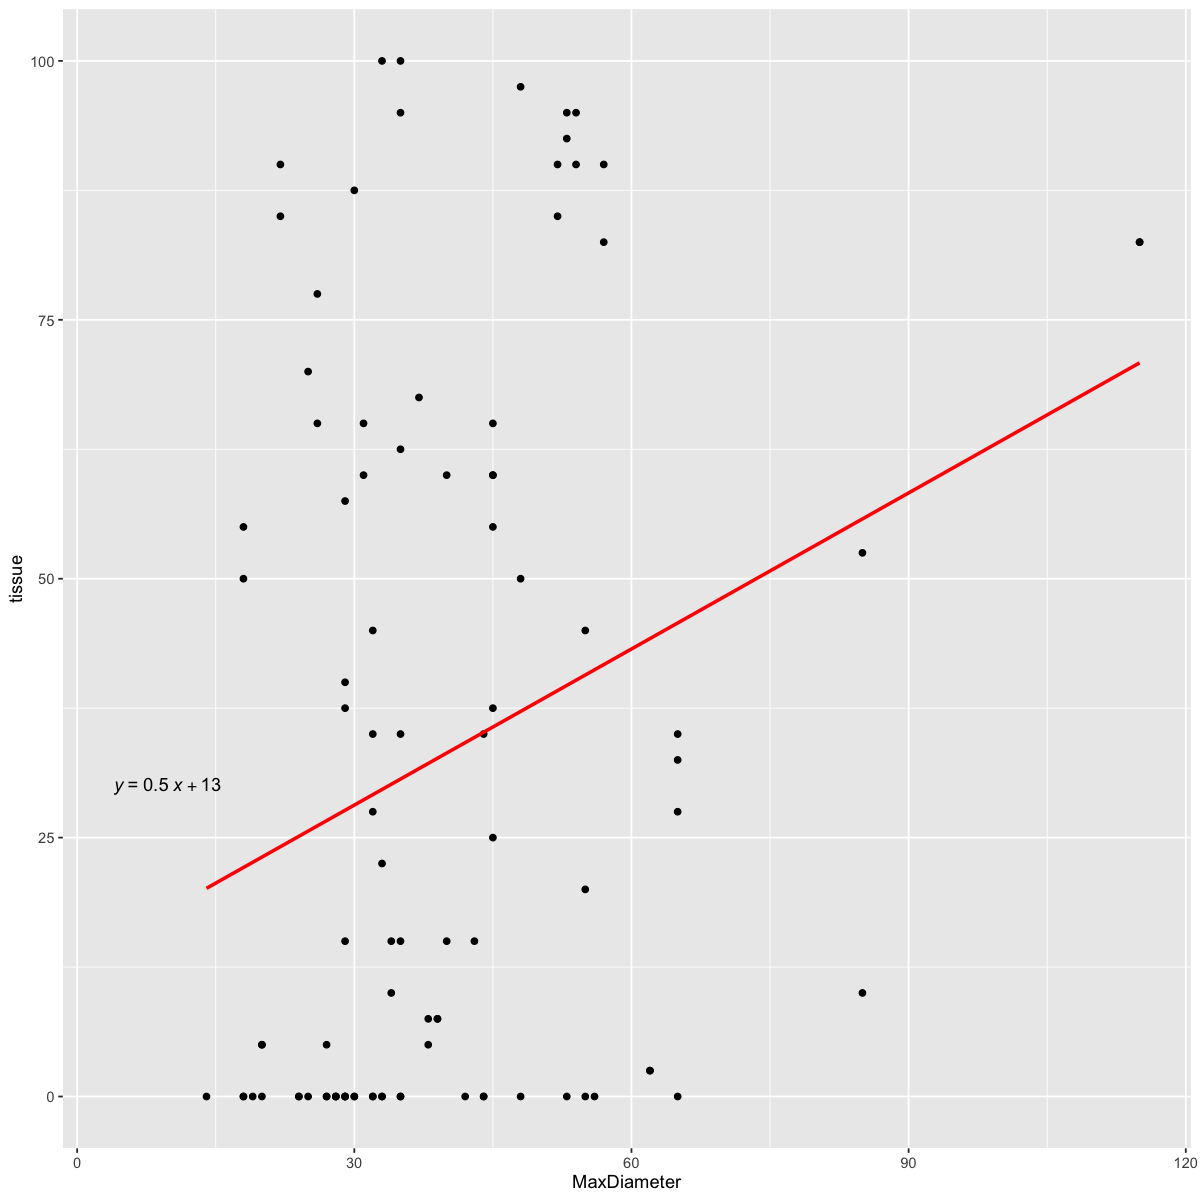

In [80]:
# plot size x live tissue
#overall 
ggplot(tl_stats, aes(x = MaxDiameter, y = tissue))+
    geom_point()+
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    stat_regline_equation(label.x = 4, label.y = 30)   

print(paste0("Peason corr: ",
             cor(tl_stats$MaxDiameter, tl_stats$tissue,use = "complete.obs", method = "pearson")))

# and may and dec 

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


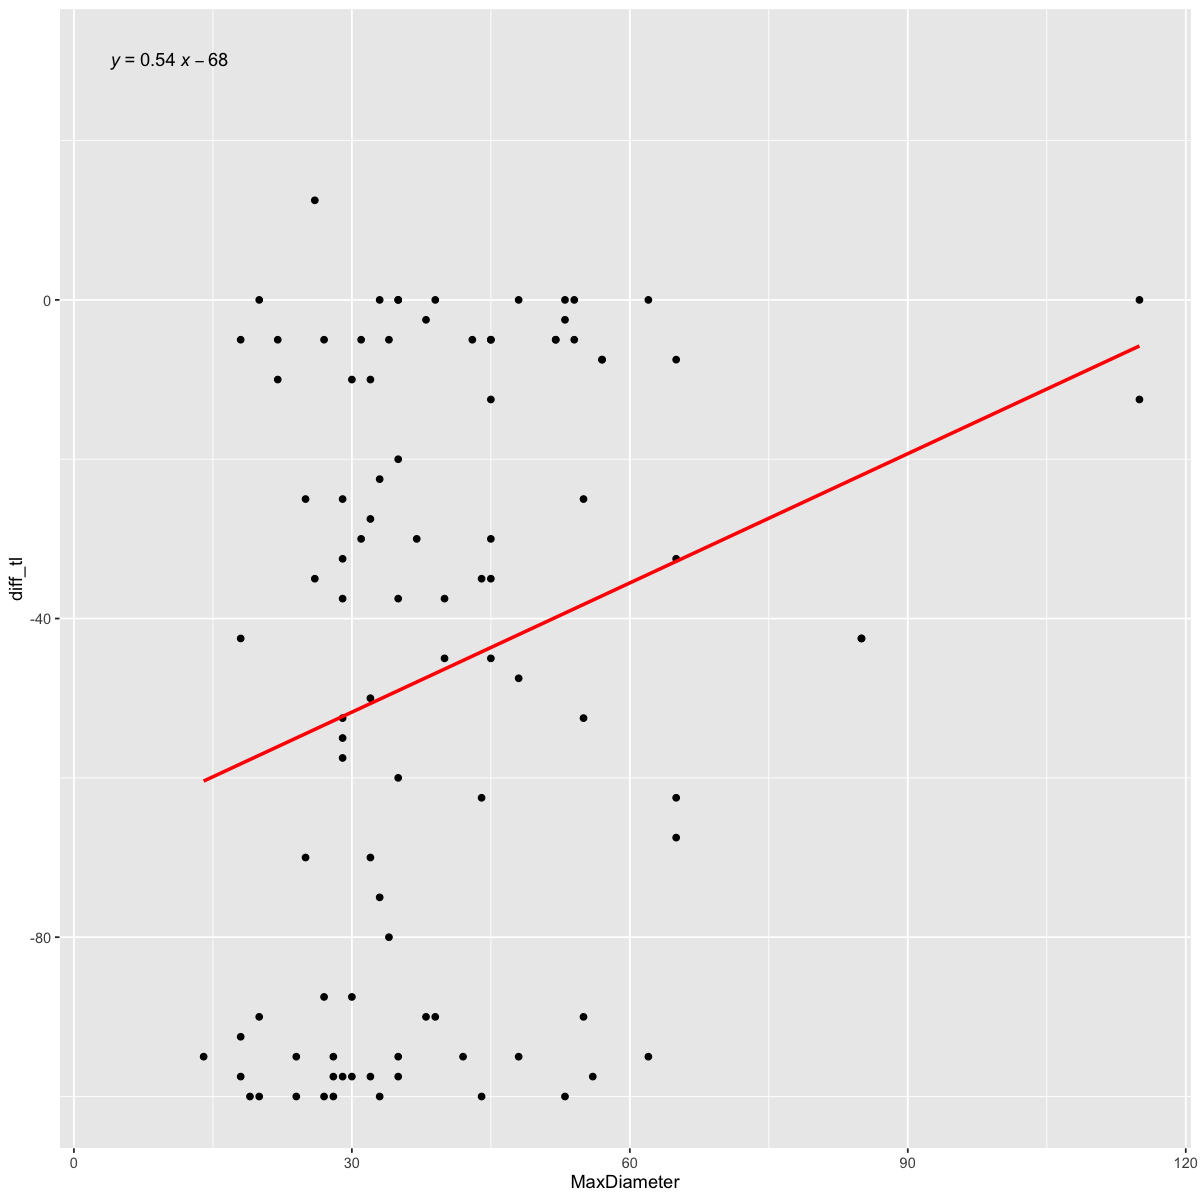

In [81]:
ggplot(tl_stats, aes(x = MaxDiameter, y = diff_tl))+
    geom_point()+
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    stat_regline_equation(label.x = 4, label.y = 30)   

In [82]:
head(tl_stats)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Size_Class,MaxDiameter,Height,Date_DocumentedDisease,Date_DocumentedMortality,⋯,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd,prop_tissue
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,14,MCAV,3,25,24,5/21/2022,12/2/2022,⋯,70.0,Diseased,05/21/22,2022-05-21,151.71429,-25.0,-0.16,-26.31579,-0.17,0.700
6/24/2019,CBC30N,1,14,MCAV,3,25,24,5/21/2022,12/2/2022,⋯,0.0,Dead,NA,2022-12-02,27.85714,-70.0,-2.51,-100.00000,-3.59,0.000
6/26/2019,CBC30N,1,15,MCAV,5,33,24,5/21/2022,12/2/2022,⋯,22.5,Diseased,05/21/22,2022-05-21,151.42857,-75.0,-0.50,-76.92308,-0.51,0.225
6/26/2019,CBC30N,1,15,MCAV,5,33,24,5/21/2022,12/2/2022,⋯,0.0,Dead,NA,2022-12-02,27.85714,-22.5,-0.81,-100.00000,-3.59,0.000
6/21/2019,CBC30N,1,329,MCAV,4,29,19,Unknown,5/21/2022,⋯,0.0,Dead,NA,2022-05-25,152.71429,-97.5,-0.64,-100.00000,-0.65,0.000
6/21/2019,CBC30N,1,333,MCAV,3,20,19,Unknown,5/21/2022,⋯,0.0,Dead,NA,2022-05-25,152.71429,-100.0,-0.65,-100.00000,-0.65,0.000


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] "Spearman corr: 0.126480665653061"


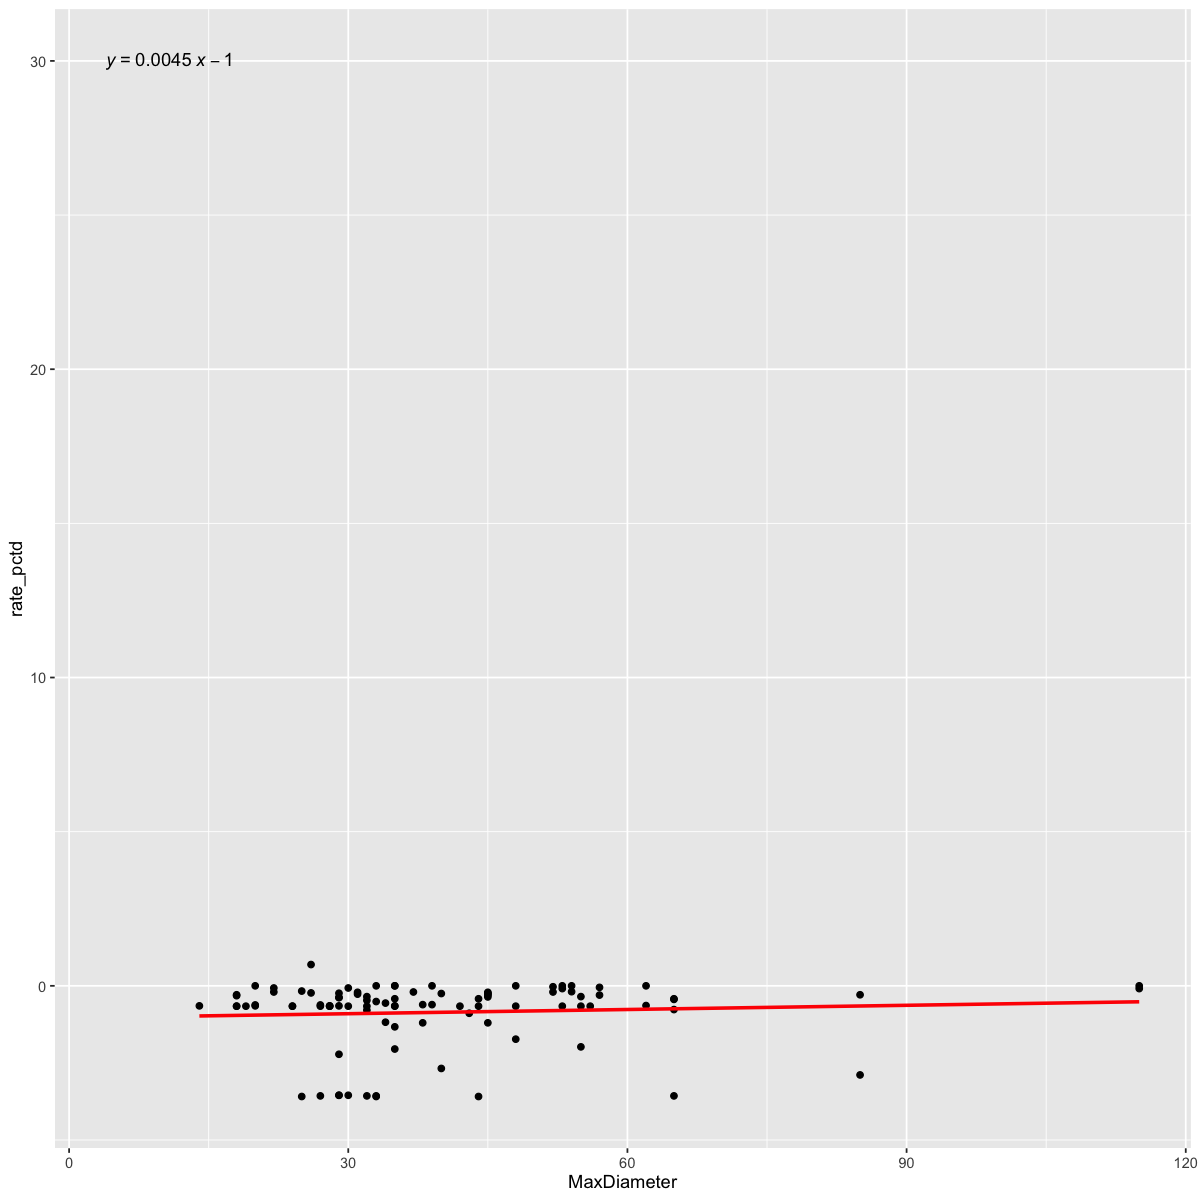

In [83]:
ggplot(tl_stats, aes(x = MaxDiameter, y = rate_pctd))+
    geom_point()+
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    stat_regline_equation(label.x = 4, label.y = 30)   

print(paste0("Spearman corr: ",
             cor(tl_stats$MaxDiameter, tl_stats$rate_pctd,use = "complete.obs", method = "spearman")))

In [84]:
result<-cor.test(tl_stats$MaxDiameter, tl_stats$rate_pctd,use = "complete.obs", method = "spearman")
# result <- cor.test(x, y, method = "spearman")
print(result)

Warning message in cor.test.default(tl_stats$MaxDiameter, tl_stats$rate_pctd, use = "complete.obs", :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  tl_stats$MaxDiameter and tl_stats$rate_pctd
S = 132859, p-value = 0.217
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.1264807 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


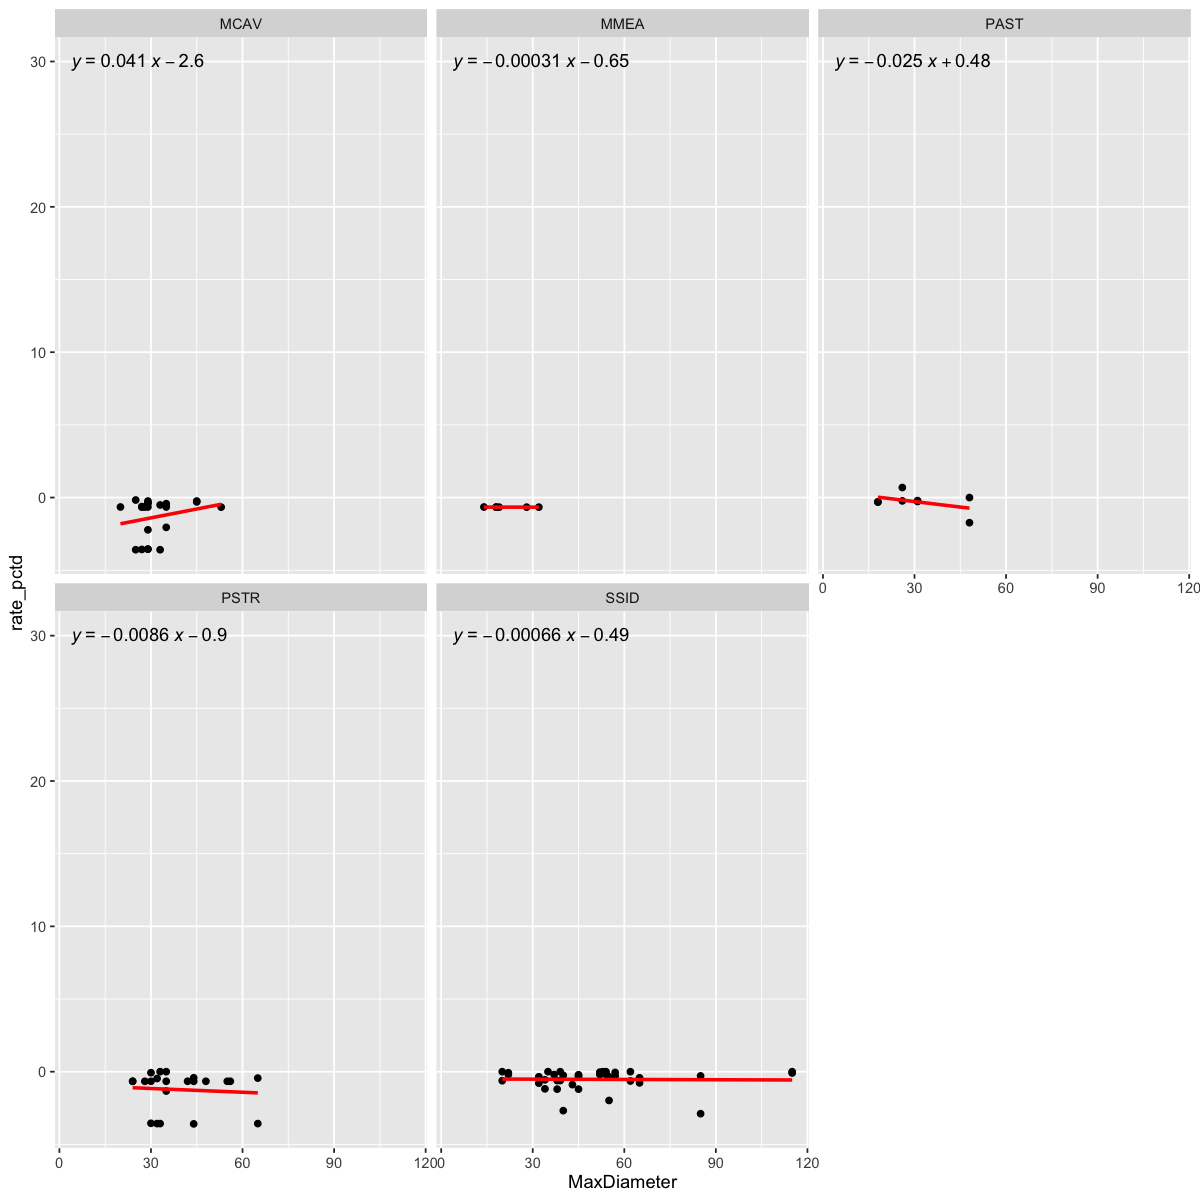

In [85]:
ggplot(tl_stats, aes(x = MaxDiameter, y = rate_pctd))+
    geom_point()+
    facet_wrap(~Species)+
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    stat_regline_equation(label.x = 4, label.y = 30)   

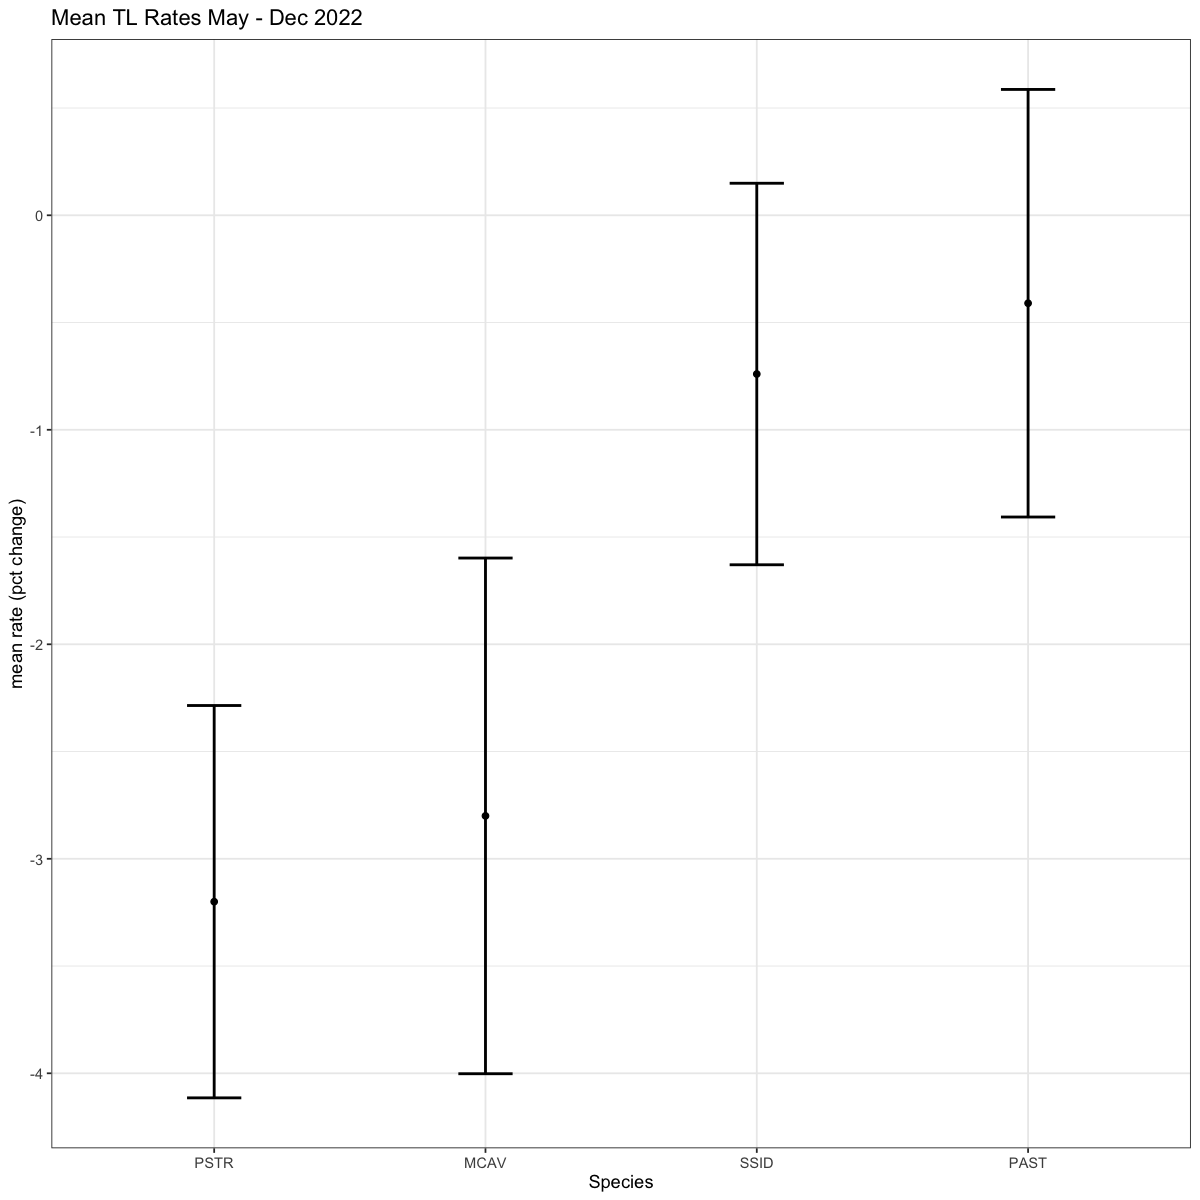

In [86]:
# just look at Dec: mean rates

ggplot(rates_plot%>%filter(metric=="pctd" & my == "Dec 2022"),
       aes(x = fct_reorder(Species,mean), y = mean))+
    geom_point()+
    geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd),width = 0.2,color = "black",linewidth = 0.8)+
    theme_bw()+
    labs(title = "Mean TL Rates May - Dec 2022",
        x = "Species", y = "mean rate (pct change)")

In [87]:
# PSTR closely followed by MCAV has highest TL
# SSID and PAST with lowest

# MCAV AND PSTR sig higher rates than SSID
# PSTR sig higher rate than PAST

In [88]:
##### MAY ######

In [89]:
tl_may <- tl_stats %>%
    filter(Date == "052022")

In [90]:
tl_may %>%
    kruskal_test(rate_pctd ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_may %>%
  dunn_test(rate_pctd ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_pctd,65,22.94293,4,0.0001299938,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_pctd,MCAV,MMEA,15,9,-2.380777866,1.727613e-02,0.1727612619,ns
2,rate_pctd,MCAV,PAST,15,5,1.352225526,1.763032e-01,1.0000000000,ns
3,rate_pctd,MCAV,PSTR,15,16,-0.923458928,3.557681e-01,1.0000000000,ns
4,rate_pctd,MCAV,SSID,15,20,2.052296759,4.014083e-02,0.4014083084,ns
5,rate_pctd,MMEA,PAST,9,5,3.051616474,2.276127e-03,0.0227612722,*
6,rate_pctd,MMEA,PSTR,9,16,1.612644299,1.068218e-01,1.0000000000,ns
7,rate_pctd,MMEA,SSID,9,20,4.247320082,2.163428e-05,0.0002163428,***
8,rate_pctd,PAST,PSTR,5,16,-2.010696149,4.435756e-02,0.4435756110,ns
9,rate_pctd,PAST,SSID,5,20,0.005413072,9.956810e-01,1.0000000000,ns


### Tissue Loss

In [91]:
# look at avg tissue loss between species 2019 -> may 2022 ?? 
    # or could do over entire period?? this might make sense but need to recalculate

# i think pct change makes sense here??

In [92]:
min(tl_stats$fulldate)
max(tl_stats$fulldate)

[1] "2022-05-20"

[1] "2022-12-04"

In [93]:
tl_stats<-tl_stats %>%
    mutate(my = factor(format(my(Date), "%b %Y"),levels = c('May 2022','Dec 2022')))

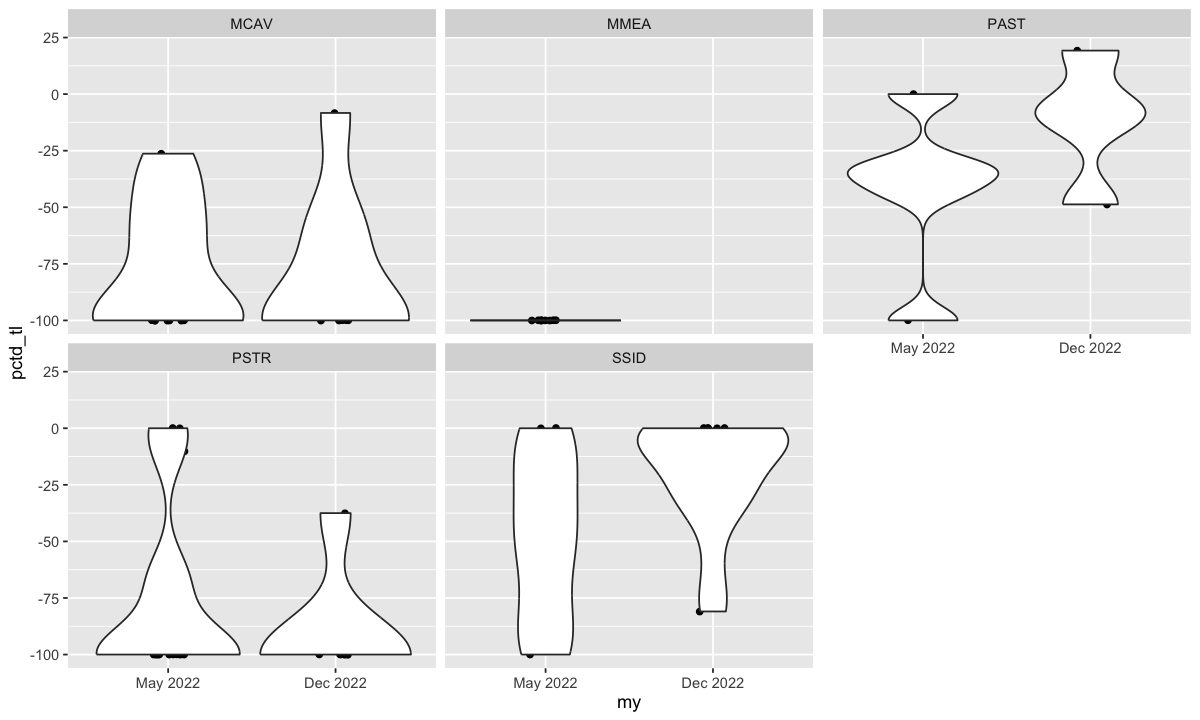

In [94]:
# box plot of pctd per species
options(repr.plot.height = 6, repr.plot.wdth = 4)
ggplot(tl_stats, aes(x = my, y = pctd_tl)) +
    geom_jitter(width = 0.1, height = 0.1)+
    geom_violin()+
    facet_wrap(~Species)

In [95]:
##### MAY ######

In [96]:
tl_may %>%
    kruskal_test(pctd_tl ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_may %>%
  dunn_test(pctd_tl ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
pctd_tl,65,22.73266,4,0.0001431879,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,pctd_tl,MCAV,MMEA,15,9,-1.97946351,4.776384e-02,0.4776384407,ns
2,pctd_tl,MCAV,PAST,15,5,1.70522437,8.815259e-02,0.8815258610,ns
3,pctd_tl,MCAV,PSTR,15,16,-0.33216259,7.397665e-01,1.0000000000,ns
4,pctd_tl,MCAV,SSID,15,20,2.50136108,1.237170e-02,0.1237169701,ns
5,pctd_tl,MMEA,PAST,9,5,3.07506476,2.104568e-03,0.0210456848,*
6,pctd_tl,MMEA,PSTR,9,16,1.71656795,8.605814e-02,0.8605814314,ns
7,pctd_tl,MMEA,SSID,9,20,4.20789592,2.577595e-05,0.0002577595,***
8,pctd_tl,PAST,PSTR,5,16,-1.95170750,5.097294e-02,0.5097294165,ns
9,pctd_tl,PAST,SSID,5,20,-0.05239324,9.582154e-01,1.0000000000,ns


In [97]:
# in may,
    # MMEA had sig higher relative TL than PAST and SSID
    # PSTR had sig higher relative TL than SSID

In [98]:
###### TOTAL TL: all time points #####

In [99]:
# try to recalculate total tissue loss over the entire period 
    # 2019 - last known live time point for each colony

In [100]:
# extract Species, colony id, tl, condition, date
total_tl<-tld %>%
    select(colony_id,Species,Transect,Date,fulldate,tissue,Condition)

In [101]:
# subtract tissue from last live time point - first time point
    # both time points vary for each colony so add labels

In [102]:
# add labels for first and last time points for each colony - all else is NA
total_tl<-total_tl %>%
    group_by(colony_id) %>%
    arrange(fulldate, .by_group = TRUE) %>%
    mutate(timepoint = case_when(
        row_number() == 1 ~ "First",
        row_number() == n() ~ "Last",
        TRUE ~ NA)) %>%
    ungroup()

In [103]:
# subtract tissue from last live time point - first time point
total_long<-total_tl %>%
    filter(!(is.na(timepoint))) %>%
    select(colony_id, Species, timepoint, tissue) %>%
    pivot_wider(names_from = timepoint, 
                values_from = tissue) %>%
    # total tissue loss over whole time period for each colony
    # and pct diff TL over whole time period for each colony
    mutate(diff_tl = Last - First,
          pctd_tl = (Last-First)/First*100) %>%
    filter(!(is.na(diff_tl))) # some colonies that were tagged in dec 2022 end up w/ na
head(total_long)

colony_id,Species,First,Last,diff_tl,pctd_tl
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
T1_DLAB_27,DLAB,97.5,92.5,-5.0,-5.128205
T1_MCAV_14,MCAV,95.0,0.0,-95.0,-100.000000
T1_MCAV_15,MCAV,97.5,0.0,-97.5,-100.000000
T1_MCAV_329,MCAV,97.5,0.0,-97.5,-100.000000
T1_MCAV_333,MCAV,100.0,0.0,-100.0,-100.000000
T1_MCAV_342,MCAV,97.5,0.0,-97.5,-100.000000


In [104]:
# remove low occurance spp 
total_long<-total_long %>%
    group_by(Species) %>%
    filter(n() >= 3) %>%
    ungroup()

In [105]:
# compare spp total tl
total_long %>%
    kruskal_test(pctd_tl ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

total_long %>%
  dunn_test(pctd_tl ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
pctd_tl,67,42.39868,4,1.379059e-08,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,pctd_tl,MCAV,MMEA,15,9,-0.7942393,4.270561e-01,1.000000e+00,ns
2,pctd_tl,MCAV,PAST,15,5,2.5060433,1.220907e-02,1.220907e-01,ns
3,pctd_tl,MCAV,PSTR,15,16,-0.5813774,5.609861e-01,1.000000e+00,ns
4,pctd_tl,MCAV,SSID,15,22,4.4241995,9.680055e-06,9.680055e-05,****
5,pctd_tl,MMEA,PAST,9,5,2.9205337,3.494324e-03,3.494324e-02,*
6,pctd_tl,MMEA,PSTR,9,16,0.3022440,7.624661e-01,1.000000e+00,ns
7,pctd_tl,MMEA,SSID,9,22,4.5902867,4.426376e-06,4.426376e-05,****
8,pctd_tl,PAST,PSTR,5,16,-2.9336744,3.349754e-03,3.349754e-02,*
9,pctd_tl,PAST,SSID,5,22,0.3780650,7.053823e-01,1.000000e+00,ns


In [106]:
# overall differences - relative change in live tissue 
    # MMEA sig greater than PAST and SSID
    # MCAV sig greater than SSID 
    # PSTR sig greater than SSID and PAST

## GLMM 

In [107]:
# try live tissue ~ timepoint x species 
library(glmmTMB)
library(performance)
library(DHARMa)

Warning message:
“package ‘DHARMa’ was built under R version 4.4.3”
This is DHARMa 0.4.7. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa')



In [108]:
summary(tl_stats$tissue)
summary(tl_stats$prop_tissue)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00   15.00   31.21   60.00  100.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.1500  0.3121  0.6000  1.0000 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


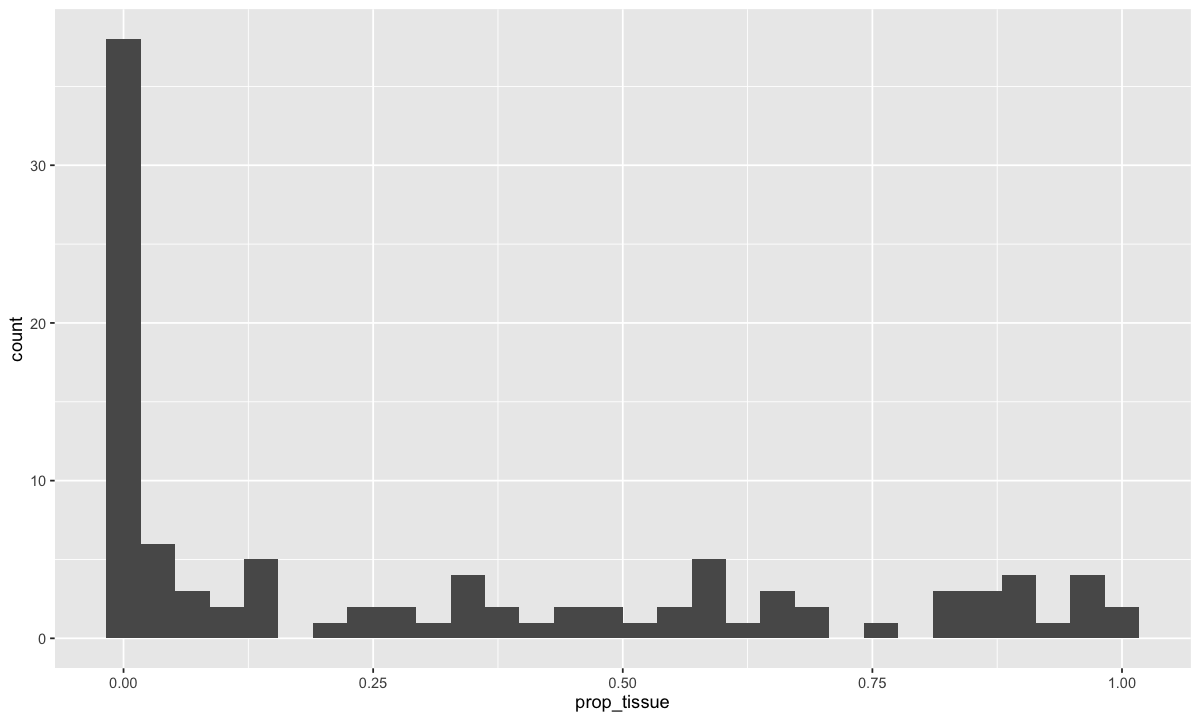

In [109]:
ggplot(tl_stats, aes(x = prop_tissue))+
    geom_histogram()

In [110]:
mean(tl_stats$prop_tissue)
var(tl_stats$prop_tissue)
# mean > variance

[1] 0.3121359

[1] 0.1199371

In [111]:
tl_stats$Species<-factor(tl_stats$Species)
tl_stats$colony_id<-factor(tl_stats$colony_id)

In [112]:
m_tl<-glmmTMB(prop_tissue ~ my * Species + (1|colony_id), 
            data = tl_stats, family = ordbeta)
summary(m_tl)
# rank deficient 

dropping columns from rank-deficient conditional model: myDec 2022:SpeciesMMEA



 Family: ordbeta  ( logit )
Formula:          prop_tissue ~ my * Species + (1 | colony_id)
Data: tl_stats

      AIC       BIC    logLik -2*log(L)  df.resid 
    107.4     141.7     -40.7      81.4        90 

Random effects:

Conditional model:
 Groups    Name        Variance Std.Dev.
 colony_id (Intercept) 3.976    1.994   
Number of obs: 103, groups:  colony_id, 67

Dispersion parameter for ordbeta family (): 16.9 

Conditional model:
                         Estimate Std. Error z value Pr(>|z|)   
(Intercept)            -1.782e+00  7.048e-01  -2.529   0.0114 * 
myDec 2022             -1.172e+00  4.203e-01  -2.788   0.0053 **
SpeciesMMEA            -2.281e+01  1.347e+04  -0.002   0.9986   
SpeciesPAST             2.265e+00  1.185e+00   1.911   0.0561 . 
SpeciesPSTR             3.381e-02  9.473e-01   0.036   0.9715   
SpeciesSSID             1.904e+00  8.298e-01   2.295   0.0218 * 
myDec 2022:SpeciesMMEA         NA         NA      NA       NA   
myDec 2022:SpeciesPAST  5.999e-01  5.7

dropping columns from rank-deficient conditional model: myDec 2022:SpeciesMMEA



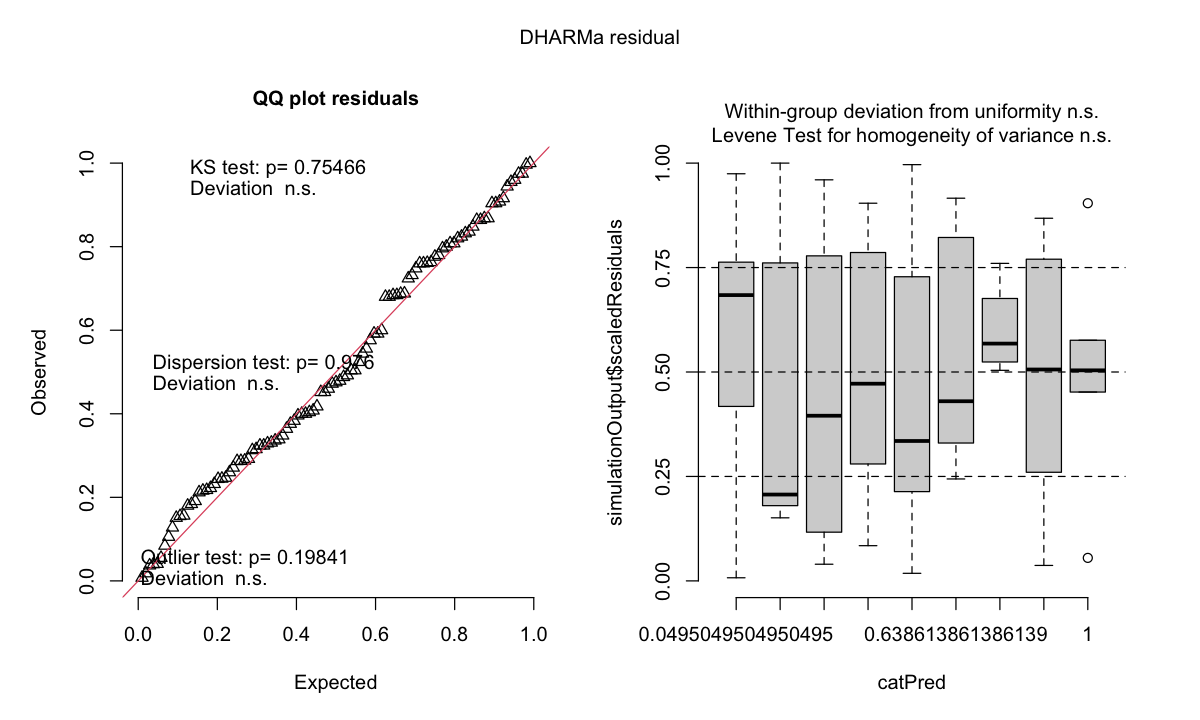

In [113]:
plot(simulateResiduals(m_tl))

In [114]:
drop1(m_tl, test = "Chisq")
# interaction is significant
# tissue loss over time differs between species

,Df,AIC,LRT,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>
<none>,NA,107.4313,NA,NA
my:Species,3,112.4211,10.98982,0.01178105


In [115]:
# car::Anova(m_tl,type="III")
# cant use bc MMEA causes rank deficiency

In [116]:
# or just rerun without MMEA?
m_tl2<-glmmTMB(prop_tissue ~ my * Species + (1|colony_id), 
            data = tl_stats%>%filter(Species != "MMEA"), family = ordbeta)
summary(m_tl2)

 Family: ordbeta  ( logit )
Formula:          prop_tissue ~ my * Species + (1 | colony_id)
Data: tl_stats %>% filter(Species != "MMEA")

      AIC       BIC    logLik -2*log(L)  df.resid 
    105.4     136.0     -40.7      81.4        82 

Random effects:

Conditional model:
 Groups    Name        Variance Std.Dev.
 colony_id (Intercept) 3.976    1.994   
Number of obs: 94, groups:  colony_id, 58

Dispersion parameter for ordbeta family (): 16.9 

Conditional model:
                       Estimate Std. Error z value Pr(>|z|)   
(Intercept)             -1.7824     0.7048  -2.529   0.0114 * 
myDec 2022              -1.1719     0.4203  -2.788   0.0053 **
SpeciesPAST              2.2645     1.1853   1.910   0.0561 . 
SpeciesPSTR              0.0338     0.9473   0.036   0.9715   
SpeciesSSID              1.9042     0.8298   2.295   0.0218 * 
myDec 2022:SpeciesPAST   0.5999     0.5757   1.042   0.2974   
myDec 2022:SpeciesPSTR  -2.9121     1.3148  -2.215   0.0268 * 
myDec 2022:SpeciesSSID   

In [117]:
car::Anova(m_tl2,type="III")
# interaction is also significant

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),6.394998,1,0.011444234
my,7.775362,1,0.005296361
Species,8.283227,3,0.040506929
my:Species,8.954916,3,0.029896343


In [118]:
library(emmeans)

Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [119]:
em1<-emmeans(m_tl, ~ my | Species, type = "response")
pairs(em1, by = "Species")
# mcav, pstr, ssid sig changed tl over time - all decreased (based on positive estimates??)
    # though notes ssid decreased the least (smallest OR)

Species = MCAV:
 contrast            odds.ratio     SE  df null z.ratio p.value
 May 2022 / Dec 2022       3.23  1.360 Inf    1   2.788  0.0053

Species = MMEA:
 contrast            odds.ratio     SE  df null z.ratio p.value
 May 2022 / Dec 2022     nonEst     NA  NA    1      NA      NA

Species = PAST:
 contrast            odds.ratio     SE  df null z.ratio p.value
 May 2022 / Dec 2022       1.77  0.694 Inf    1   1.460  0.1443

Species = PSTR:
 contrast            odds.ratio     SE  df null z.ratio p.value
 May 2022 / Dec 2022      59.38 75.400 Inf    1   3.219  0.0013

Species = SSID:
 contrast            odds.ratio     SE  df null z.ratio p.value
 May 2022 / Dec 2022       1.75  0.337 Inf    1   2.919  0.0035

Tests are performed on the log odds ratio scale 

In [120]:
em1

Species = MCAV:
 my       response       SE  df asymp.LCL asymp.UCL
 May 2022  0.14401 8.69e-02 Inf  0.040552    0.4011
 Dec 2022  0.04954 3.80e-02 Inf  0.010617    0.2020

Species = MMEA:
 my       response       SE  df asymp.LCL asymp.UCL
 May 2022  0.00000 2.80e-07 Inf  0.000000    1.0000
 Dec 2022   nonEst       NA  NA        NA        NA

Species = PAST:
 my       response       SE  df asymp.LCL asymp.UCL
 May 2022  0.61827 2.35e-01 Inf  0.187647    0.9191
 Dec 2022  0.47756 2.50e-01 Inf  0.113488    0.8671

Species = PSTR:
 my       response       SE  df asymp.LCL asymp.UCL
 May 2022  0.14823 9.90e-02 Inf  0.036057    0.4474
 Dec 2022  0.00292 4.44e-03 Inf  0.000148    0.0549

Species = SSID:
 my       response       SE  df asymp.LCL asymp.UCL
 May 2022  0.53042 1.13e-01 Inf  0.317378    0.7329
 Dec 2022  0.39195 1.08e-01 Inf  0.209298    0.6109

Confidence level used: 0.95 
Intervals are back-transformed from the logit scale 

In [121]:
as.data.frame(pairs(em1, by = "my")) %>% mutate(sig = if_else(p.value < 0.05, "YES","NO"))
# no sig diffs in tissue loss in May 2022 between Species
# and in Dec 2022, 
    # MCAV sig diff from ssid
        # MCAV had greater TL than SSID
    # PSTR sig diff from PAST and SSID
        # PSTR had sig more TL than PAST and SSID

,contrast,my,odds.ratio,SE,df,null,z.ratio,p.value,sig
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,MCAV / MMEA,May 2022,8.055217e+09,1.085096e+14,Inf,1,0.001693271,1.000000000,NO
2,MCAV / PAST,May 2022,1.038768e-01,1.231296e-01,Inf,1,-1.910460102,0.311612638,NO
3,MCAV / PSTR,May 2022,9.667563e-01,9.157879e-01,Inf,1,-0.035690490,0.999999633,NO
4,MCAV / SSID,May 2022,1.489419e-01,1.235990e-01,Inf,1,-2.294638882,0.146504649,NO
5,MMEA / PAST,May 2022,1.289559e-11,1.737130e-07,Inf,1,-0.001861379,1.000000000,NO
6,MMEA / PSTR,May 2022,1.200162e-10,1.616705e-06,Inf,1,-0.001695780,1.000000000,NO
7,MMEA / SSID,May 2022,1.849012e-11,2.490754e-07,Inf,1,-0.001834629,1.000000000,NO
8,PAST / PSTR,May 2022,9.306757e+00,1.144381e+01,Inf,1,1.814164985,0.365238644,NO
9,PAST / SSID,May 2022,1.433832e+00,1.561978e+00,Inf,1,0.330787491,0.997421933,NO


In [122]:
# results from glmm are the same as kruskal wallis yay 

### With 2019

In [123]:
tld_m<-tld %>%
    filter(!(Species %in% c('OANN','OFAV','DLAB'))) %>%
    mutate(my = format(as.Date(fulldate), "%b %Y")) %>%
    mutate(my = if_else(my == "Jun 2019","Oct 2019",my)) %>%
    mutate(my = factor(my,levels = c("Oct 2019","May 2022","Dec 2022"))) %>%
    mutate(prop_tissue = tissue/100)

In [124]:
tld_m$colony_id<-factor(tld_m$colony_id)
tld_m$Species<-factor(tld_m$Species)

In [125]:
summary(tld_m$tissue)
summary(tld_m$prop_tissue)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    6.25   67.50   56.71   95.00  100.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0625  0.6750  0.5671  0.9500  1.0000 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


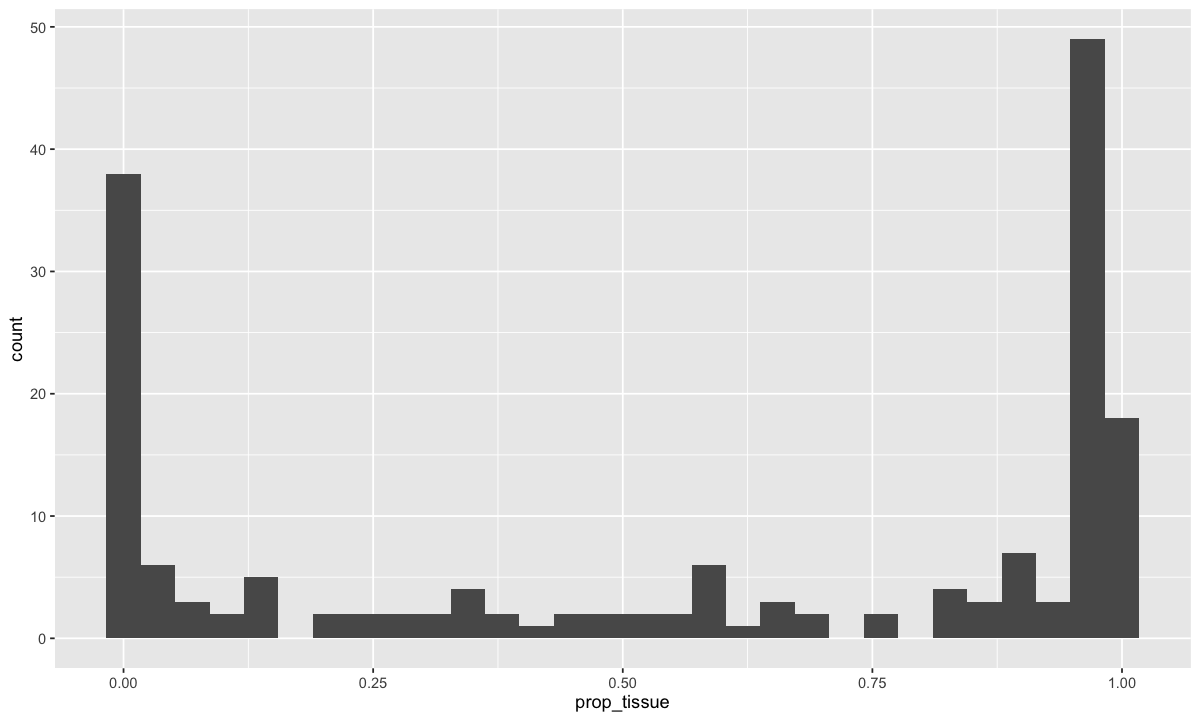

In [126]:
ggplot(tld_m, aes(x = prop_tissue))+
    geom_histogram()

In [127]:
mean(tld_m$prop_tissue)
var(tld_m$prop_tissue)
# mean > variance

[1] 0.5671429

[1] 0.1715794

In [128]:
m_tl3<-glmmTMB(prop_tissue ~ my * Species + (1|colony_id), 
            data = tld_m, family = ordbeta)
summary(m_tl3)
# rank deficient 

dropping columns from rank-deficient conditional model: myDec 2022:SpeciesMMEA



 Family: ordbeta  ( logit )
Formula:          prop_tissue ~ my * Species + (1 | colony_id)
Data: tld_m

      AIC       BIC    logLik -2*log(L)  df.resid 
     83.8     140.7     -23.9      47.8       157 

Random effects:

Conditional model:
 Groups    Name        Variance Std.Dev.
 colony_id (Intercept) 1.264    1.124   
Number of obs: 175, groups:  colony_id, 72

Dispersion parameter for ordbeta family (): 12.8 

Conditional model:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)             3.104e+00  4.209e-01   7.374 1.66e-13 ***
myMay 2022             -3.397e+00  3.752e-01  -9.055  < 2e-16 ***
myDec 2022             -3.908e+00  4.874e-01  -8.018 1.07e-15 ***
SpeciesMMEA             9.547e-01  7.573e-01   1.261   0.2074    
SpeciesPAST            -2.545e-02  7.754e-01  -0.033   0.9738    
SpeciesPSTR             4.205e-01  5.616e-01   0.749   0.4541    
SpeciesSSID             1.842e-01  5.031e-01   0.366   0.7142    
myMay 2022:SpeciesMMEA -2.447e+01

dropping columns from rank-deficient conditional model: myDec 2022:SpeciesMMEA



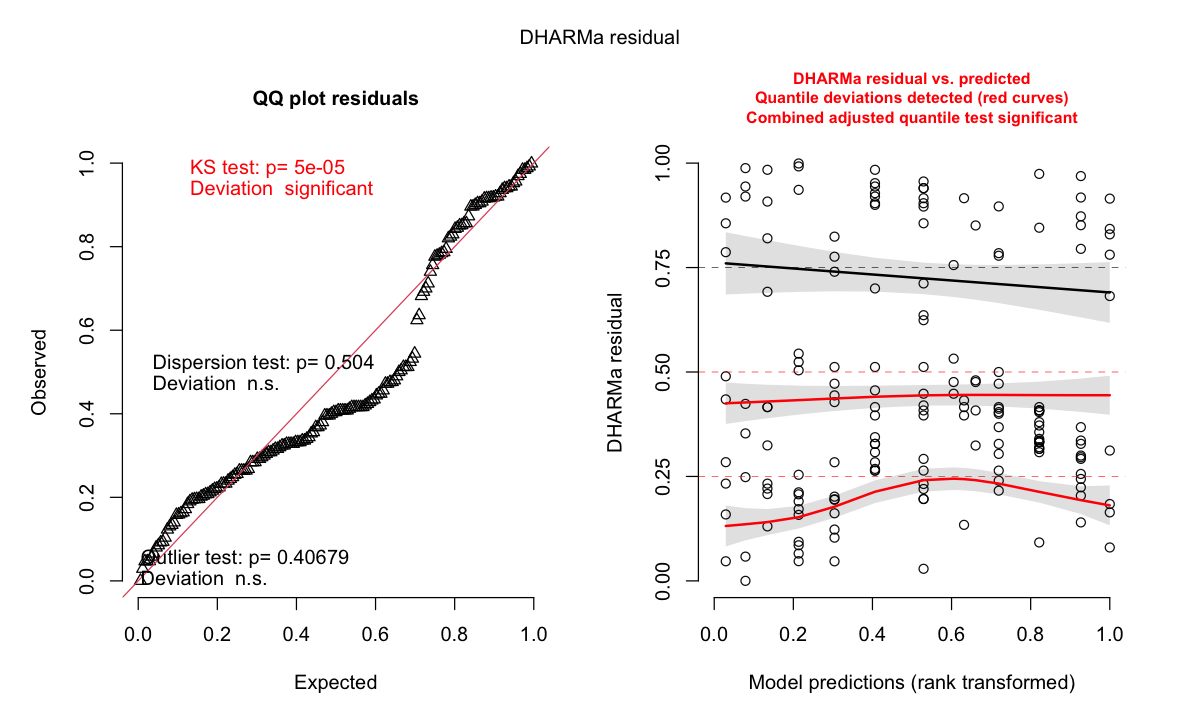

In [129]:
plot(simulateResiduals(m_tl3))
# not as good a fit but not terrible

In [130]:
drop1(m_tl3, test = "Chisq")
# interaction is significant

,Df,AIC,LRT,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>
<none>,NA,83.75185,NA,NA
my:Species,7,104.63474,34.88289,1.17657e-05


In [131]:
em3<-emmeans(m_tl3, ~ my | Species, type = "response")
em3

Species = MCAV:
 my       response       SE  df asymp.LCL asymp.UCL
 Oct 2019    0.957 1.73e-02 Inf    0.9071     0.981
 May 2022    0.427 8.94e-02 Inf    0.2672     0.604
 Dec 2022    0.309 8.80e-02 Inf    0.1664     0.501

Species = MMEA:
 my       response       SE  df asymp.LCL asymp.UCL
 Oct 2019    0.983 1.16e-02 Inf    0.9366     0.996
 May 2022    0.000 8.00e-07 Inf    0.0000     1.000
 Dec 2022   nonEst       NA  NA        NA        NA

Species = PAST:
 my       response       SE  df asymp.LCL asymp.UCL
 Oct 2019    0.956 2.89e-02 Inf    0.8496     0.988
 May 2022    0.719 1.22e-01 Inf    0.4402     0.893
 Dec 2022    0.588 1.46e-01 Inf    0.3051     0.822

Species = PSTR:
 my       response       SE  df asymp.LCL asymp.UCL
 Oct 2019    0.971 1.29e-02 Inf    0.9320     0.988
 May 2022    0.388 1.07e-01 Inf    0.2079     0.605
 Dec 2022    0.197 1.07e-01 Inf    0.0617     0.479

Species = SSID:
 my       response       SE  df asymp.LCL asymp.UCL
 Oct 2019    0.964 1.35e-02 Inf 

In [132]:
pairs(em3, by = "Species")

Species = MCAV:
 contrast            odds.ratio       SE  df null z.ratio p.value
 Oct 2019 / May 2022   3.00e+01 1.10e+01 Inf    1   9.055 <0.0001
 Oct 2019 / Dec 2022   5.00e+01 2.40e+01 Inf    1   8.018 <0.0001
 May 2022 / Dec 2022   2.00e+00 1.00e+00 Inf    1   1.328  0.3795

Species = MMEA:
 contrast            odds.ratio       SE  df null z.ratio p.value
 Oct 2019 / May 2022   1.26e+12 2.21e+16 Inf    1   0.002  0.9987
 Oct 2019 / Dec 2022     nonEst       NA  NA    1      NA      NA
 May 2022 / Dec 2022     nonEst       NA  NA    1      NA      NA

Species = PAST:
 contrast            odds.ratio       SE  df null z.ratio p.value
 Oct 2019 / May 2022   8.00e+00 5.00e+00 Inf    1   3.649  0.0008
 Oct 2019 / Dec 2022   1.50e+01 9.00e+00 Inf    1   4.575 <0.0001
 May 2022 / Dec 2022   2.00e+00 1.00e+00 Inf    1   1.369  0.3573

Species = PSTR:
 contrast            odds.ratio       SE  df null z.ratio p.value
 Oct 2019 / May 2022   5.30e+01 2.70e+01 Inf    1   7.894 <0.0001
 Oct 2019

In [133]:
# all spp significantly lost tissue from oct 2019 - both May AND Dec 2022
    # (except MMEA but thats bc of complete separation..all went from 95 or 100 to 0)

# SSID significantly lost tissue from May -> Dec 2022
    # when running model with only may and dec though all spp were significant here

In [134]:
as.data.frame(pairs(em3, by = "my")) %>% mutate(sig = if_else(p.value < 0.05, "YES","NO"))
# ok and now nothing is significant here

,contrast,my,odds.ratio,SE,df,null,z.ratio,p.value,sig
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,MCAV / MMEA,Oct 2019,3.849290e-01,2.915043e-01,Inf,1,-1.260668748,0.7154014,NO
2,MCAV / PAST,Oct 2019,1.025777e+00,7.953694e-01,Inf,1,0.032822761,0.9999997,NO
3,MCAV / PSTR,Oct 2019,6.567340e-01,3.688408e-01,Inf,1,-0.748672782,0.9449079,NO
4,MCAV / SSID,Oct 2019,8.317453e-01,4.184498e-01,Inf,1,-0.366188674,0.9961721,NO
5,MMEA / PAST,Oct 2019,2.664846e+00,2.507228e+00,Inf,1,1.041763826,0.8359186,NO
6,MMEA / PSTR,Oct 2019,1.706117e+00,1.290961e+00,Inf,1,0.706017998,0.9552007,NO
7,MMEA / SSID,Oct 2019,2.160776e+00,1.574721e+00,Inf,1,1.057207445,0.8283738,NO
8,PAST / PSTR,Oct 2019,6.402309e-01,5.063218e-01,Inf,1,-0.563862446,0.9802216,NO
9,PAST / SSID,Oct 2019,8.108444e-01,6.068828e-01,Inf,1,-0.280148262,0.9986545,NO
